## Library

In [57]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os
import statistics
import seaborn as sns
from scipy import stats
import numpy as np
import tifffile
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker


os.chdir(r"Z:\Vaissiere\2025-12 - state experiment\state_airpuff")
from ALLmethods import *

def plot_multiple_correlations(data, x_vars, y_var, n_cols=3, fsize=(4, 4)):
    """
    Plots multiple correlations in a grid of subplots.
    x_vars: List of column names to plot on the X-axis against y_var.
    n_cols: How many plots wide the grid should be.
    """
    sns.set_theme(style="ticks")
    
    # Calculate how many rows are needed
    n_plots = len(x_vars)
    n_rows = math.ceil(n_plots / n_cols)
    
    # Scale total figure size based on the number of rows and columns
    fig_width = n_cols * fsize[0]
    fig_height = n_rows * fsize[1]
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(fig_width, fig_height), sharey=True)
    
    # Flatten the axes array so we can easily loop through it in 1D
    # (Handles edge case where there's only 1 subplot)
    if n_plots == 1:
        axes = np.array([axes])
    axes = axes.flatten()
    
    for i, x_var in enumerate(x_vars):
        ax = axes[i]
        
        # 1. Scatter and regression line plotted on this specific 'ax'
        sns.regplot(
            data=data, 
            x=x_var, 
            y=y_var, 
            scatter_kws={'alpha': 0.8}, 
            line_kws={'color': 'blue', 'linewidth': 2},
            ax=ax
        )
        
        # 2. Clean data and calculate stats
        valid = pd.notna(data[x_var]) & pd.notna(data[y_var])
        x_clean = data.loc[valid, x_var]
        y_clean = data.loc[valid, y_var]
        
        if len(x_clean) >= 2:
            r, p_val = stats.pearsonr(x_clean, y_clean)
            r2 = r ** 2
            
            text = f"$R^2$ = {r2:.2f}\n$p$ = {p_val:.3f}" if p_val >= 0.001 else f"$R^2$ = {r2:.2f}\n$p$ < 0.001"
            
            # 3. Annotate specifically on this subplot
            ax.annotate(
                text, 
                xy=(0.05, 0.95), 
                xycoords='axes fraction',
                verticalalignment='top',
                fontsize=10, 
                bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray', alpha=0.8)
            )
        
        ax.set_title(f"{x_var} vs {y_var}", fontsize=11, pad=10)
        
    # 4. Hide any extra empty subplots if your x_vars don't fill the final row
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
        
    sns.despine()
    plt.tight_layout()
    plt.show()

def get_multiple_cv(df, group_col='Target_ID', measure_cols=None):
    """
    Groups a dataframe by a specific column and calculates the 
    Coefficient of Variation (CV) percentage for multiple measure columns.
    Returns a long-format DataFrame.
    """
    # Using mutable default arguments (like a list) in the function signature is risky in Python. 
    # It's safer to default to None and set the list inside the function.
    if measure_cols is None:
        measure_cols = ['norm intensity']

    # 1. Group by the target column and calculate std and mean
    grouped = df.groupby(group_col)[measure_cols]
    
    std_df = grouped.std()
    mean_df = grouped.mean()
    
    # 2. Calculate CV (Standard Deviation / Mean) and convert to percentage
    cv_df = (std_df / mean_df) * 100
    
    # 3. Rename columns and save the reset index so group_col becomes a standard column
    cv_df = cv_df.add_suffix('_CV_Percentage')
    cv_df = cv_df.reset_index() 
    
    # 4. Melt into long format dynamically
    df_long = pd.melt(
        cv_df,
        id_vars=[group_col], # Uses your parameter instead of a hardcoded string
        # By omitting 'value_vars', pandas automatically melts all remaining columns. 
        # This makes the function infinitely reusable regardless of what measure_cols you pass in.
        var_name='type',           
        value_name='CV'            
    )
    
    return df_long

def extract_and_plot_tiles(tiff_paths, start_z, x, y, width=30, height=30, num_tiles=10, image_names=None):
    """
    Extracts tiles from multiple TIFF z-stacks and plots them in a grid.
    
    Parameters:
    - tiff_paths (list of str): List containing paths to the TIFF files.
    - start_z (int): The starting z-index slice.
    - x (int): X-coordinate of the top-left corner.
    - y (int): Y-coordinate of the top-left corner.
    - width (int): Width of the cropped tile.
    - height (int): Height of the cropped tile.
    - num_tiles (int): Number of z-slices to extract (default is 10).
    - image_names (list of str, optional): List of names for the row labels.
    """
    
    # -----------------------------------------
    # 1. Extract the cropped tiles
    # -----------------------------------------
    all_image_tiles = []
    end_z = start_z + num_tiles
    
    for tiff_path in tiff_paths:
        with tifffile.TiffFile(tiff_path) as tif:
            single_image_tiles = []
            for z in range(start_z, end_z):
                # Read the specific z-slice
                slice_img = tif.pages[z].asarray()
                # Crop using the coordinates
                tile = slice_img[y:y+height, x:x+width]
                single_image_tiles.append(tile)
                
            all_image_tiles.append(single_image_tiles)

    # -----------------------------------------
    # 2. Plot the tiles in a grid
    # -----------------------------------------
    num_rows = len(all_image_tiles)
    num_cols = num_tiles
    
    # Create the figure
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 2, num_rows * 2))
    
    # Ensure axes is always a 2D array even if there is only 1 row or column
    if num_rows == 1:
        axes = np.array([axes])
    if num_cols == 1:
        axes = axes[:, np.newaxis]
        
    for r in range(num_rows):
        for c in range(num_cols):
            ax = axes[r, c]
            tile = all_image_tiles[r][c]
            current_z = start_z + c
            
            # Display the tile
            ax.imshow(tile, cmap='gray')
            
            # Remove axis ticks for a cleaner grid
            ax.set_xticks([])
            ax.set_yticks([])
            
            # Add column labels (z-slices) on the top row
            if r == 0:
                ax.set_title(f"Z = {current_z}", fontsize=12)
                
            # Add row labels (image source) on the leftmost column
            if c == 0:
                label = image_names[r] if image_names else f"Image {r+1}"
                # Set ylabel and make it visible even with ticks turned off
                ax.set_ylabel(label, fontsize=12, rotation=90, labelpad=10)
                # We need to manually turn the y-axis back on (just the label line) since we removed ticks
                ax.spines['left'].set_visible(False) 

    # Adjust layout so titles and labels don't overlap
    plt.tight_layout()
    plt.show()

def plot_single_correlation(data, x_var, y_var, fsize=(3, 4)):
    """
    Plots a single correlation with a regression line and stats annotated.
    Matches the aesthetic style of corr_func.
    """
    sns.set_theme(style="ticks")
    
    # ADJUST SIZE HERE (width, height)
    plt.figure(figsize=fsize) 
    
    sns.regplot(
        data=data, 
        x=x_var, 
        y=y_var, 
        scatter_kws={'alpha': 0.8}, 
        line_kws={'color': 'blue', 'linewidth': 2}
    )
    
    # Isolate variables and drop NaNs (matching corr_func logic)
    x = data[x_var]
    y = data[y_var]
    valid = pd.notna(x) & pd.notna(y)
    x_clean = x[valid]
    y_clean = y[valid]
    
    # Only calculate if we have enough data points
    if len(x_clean) >= 2:
        r, p_val = stats.pearsonr(x_clean, y_clean)
        r2 = r ** 2
        
        # Format the text display exactly like corr_func
        text = f"$R^2$ = {r2:.2f}\n$p$ = {p_val:.3f}" if p_val >= 0.001 else f"$R^2$ = {r2:.2f}\n$p$ < 0.001"
        
        # Place text in the subplot using corr_func styling
        ax = plt.gca()
        ax.annotate(
            text, 
            xy=(0.05, 0.8), 
            xycoords=ax.transAxes, 
            fontsize=10, 
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray', alpha=0.8)
        )
    
    plt.title(f"Correlation: {x_var} vs {y_var}", fontsize=12, pad=10)
    sns.despine()
    plt.tight_layout()
    plt.show()

def plot_all_cor(data, variables, mtitle='Pairwise Corr', custsize=2):
    ''' 
    data: df_measure
    variables: ['Vol_um3', 'Max_Intensity', 'Sum_Intensity', 'Area_Opt_Z_um2']
    '''
    # Set aesthetic style
    sns.set_theme(style="ticks")

    # Create pairplot with regression lines on the lower/upper triangles
    g = sns.PairGrid(data, vars=variables, height=custsize, despine=False)

    # Map scatter plots with regression lines to the off-diagonal grids
    g.map_offdiag(sns.scatterplot, alpha=0.8)
    g.map_offdiag(sns.regplot, scatter=False, color='blue', line_kws={'linewidth': 2})

    # Map histograms to the diagonal
    g.map_diag(sns.histplot, kde=True, color='blue')

    # Add R² and p-values to the upper or lower off-diagonal sections
    g.map_offdiag(corr_func)

    # Adjust layout and show
    plt.suptitle(mtitle, y=1.02, fontsize=14)
    plt.show()


# --- 2. CUSTOM FUNCTION TO ANNOTATE R² AND P-VALUE ---
def corr_func(x, y, **kwargs):
    """Calculates Pearson r, R², and p-value, then displays it on the plot."""
    # Drop rows where either x or y is NaN
    valid = pd.notna(x) & pd.notna(y)
    x_clean = x[valid]
    y_clean = y[valid]
    
    if len(x_clean) < 2:
        return
        
    r, p_val = stats.pearsonr(x_clean, y_clean)
    r2 = r ** 2
    
    # Format the text display
    text = f"$R^2$ = {r2:.2f}\n$p$ = {p_val:.3f}" if p_val >= 0.001 else f"$R^2$ = {r2:.2f}\n$p$ < 0.001"
    
    # Place text in the middle of the subplot
    ax = plt.gca()
    ax.annotate(text, xy=(0.05, 0.8), xycoords=ax.transAxes, 
                fontsize=10, bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray', alpha=0.8))

def plot_multiple_metrics(df, fsize=(3,4), x_col='Target_ID', y_cols=None):
    """
    Plots a grouped bar chart (mean + SEM) for multiple columns side-by-side, 
    overlaid with individual data points. Returns the axes object for further modification.
    """
    if y_cols is None:
        y_cols = ['norm intensity', 'percent']

    # 1. Reshape the data
    melted_df = pd.melt(
        df, 
        id_vars=[x_col], 
        value_vars=y_cols,
        var_name='Metric', 
        value_name='Value'
    )
    
    # Create the figure and axes objects explicitly
    fig, ax = plt.subplots(figsize=fsize)
    
    # 2. Plot the Grouped Bar Chart (assign it to 'ax')
    sns.barplot(
        data=melted_df, 
        x=x_col, 
        y='Value', 
        hue='Metric', 
        errorbar='se', 
        capsize=0.05,
        alpha=0.7,
        edgecolor='black',
        ax=ax
    )
    
    # 3. Overlay the Scatter Plot (assign it to 'ax')
    sns.stripplot(
        data=melted_df, 
        x=x_col, 
        y='Value', 
        hue='Metric', 
        dodge=True, 
        alpha=0.6, 
        jitter=True,
        size=5,
        linewidth=1,
        ax=ax
    )
    
    # 4. Clean up the duplicate legend
    handles, labels = ax.get_legend_handles_labels()
    n_metrics = len(y_cols)
    ax.legend(handles[:n_metrics], labels[:n_metrics], title='Metric', bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # 5. Default Formatting (Using ax methods instead of plt)
    ax.set_title(f'Comparison of {", ".join(y_cols)} by {x_col}', fontsize=14)
    ax.set_ylabel('Value', fontsize=12)
    ax.set_xlabel(x_col, fontsize=12)

    # Remove the top and right frame lines (spines)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # RETURN the axes object instead of calling plt.show()
    return ax

def get_largest_surface_area_from_tiff(tiff_path, z, x, y, width, height, threshold=0):
    """
    Loads a TIFF z-stack, extracts a z-frame, crops it using a bounding box 
    (top-left x, y with width and height), binarizes it, and returns the area 
    (in pixels) of the largest connected component.
    """
    
    # 1. Load the TIFF stack into a numpy array
    image_volume = tifffile.imread(tiff_path)
    
    # Safety check: Ensure the requested Z-slice exists
    if z < 0 or z >= image_volume.shape[0]:
        raise IndexError(f"Z-index {z} is out of bounds. The TIFF stack has {image_volume.shape[0]} slices.")
    
    # 2. Extract the specific frame
    frame = image_volume[z, :, :]
    
    # 3. Calculate crop boundaries and prevent going out-of-bounds
    max_y, max_x = frame.shape
    y_end = min(y + height, max_y)
    x_end = min(x + width, max_x)
    
    # 4. Crop based on top-left corner and calculated ends
    # numpy uses [row, col] format, which translates to [y:y_end, x:x_end]
    cropped = frame[y:y_end, x:x_end]
    
    # 5. Binarize the image
    binary_mask = cropped > threshold
    
    # 6. Detect distinct areas (connected components)
    labeled_image = measure.label(binary_mask, connectivity=2)
    regions = measure.regionprops(labeled_image)
    
    # If no non-zero pixels are found, return 0
    if not regions:
        return 0
        
    # 7. Extract the areas of all detected regions and find the max
    areas = [region.area for region in regions]
    largest_area = max(areas)
    
    return largest_area


## IntSpine within comparison 
understand the internal lab method robustness

In [3]:
path = r"Z:\2026 - E19 Project collab spine and dendrites\Respan\202607013_makingCAREmodel_deconvolution+GaussianFilter\nocare_MS\TEST1\New folder\output_analysis1"
files = glob.glob(f'{path}{os.sep}*.csv')

alldat = []
for i in files:
    if 'bla_spine_results.csv' in i:
        print('updated file')
        tmp1 = pd.read_csv(r"Z:\2026 - E19 Project collab spine and dendrites\Respan\202607013_makingCAREmodel_deconvolution+GaussianFilter\nocare_MS\TEST1\New folder\output_analysis1\bla_spine_results.csv")
        tmp2 = pd.read_csv(r"Z:\2026 - E19 Project collab spine and dendrites\Respan\202607013_makingCAREmodel_deconvolution+GaussianFilter\nocare_MS\TEST1\New folder\output_analysis\bla_spine_results.csv")
        tmp1 = tmp1[['Target_ID','Corrected_Y','Corrected_X']]
        tmp2 = tmp2.drop(columns=['Target_ID'])
        tmp = pd.merge(tmp1, tmp2, on=['Corrected_Y','Corrected_X'])
    else:
        tmp=pd.read_csv(i)
    cat = i.split(os.sep)[-1].split('_')[0]
    tmp['measure_type'] = cat
    alldat.append(tmp)
final = pd.concat(alldat, join='outer')
# final

updated file


In [4]:
measure = 'Vol_um3'
final.groupby(['Target_ID'])[measure].var()
pivot_df = final.pivot_table(
    index=['Target_ID'], 
    columns='measure_type', 
    values=measure
).reset_index()


variance_values = pivot_df[['bla', 'blm1', 'blm2']].var()
print(pivot_df[['bla', 'blm1', 'blm2']].var(axis=1))

correlation_matrix = pivot_df[['bla', 'blm1', 'blm2']].corr()
print(correlation_matrix)
pivot_df
pivot_df[['bla', 'blm1', 'blm2']].var(axis=1)
df = pivot_df[['Target_ID','bla', 'blm1', 'blm2']]
df


0     0.374715
1     0.133713
2     1.553770
3     0.360022
4     0.150765
5     0.246994
6     0.229252
7     1.898388
8     1.074116
9     0.101890
10    0.048492
11    0.254781
12    0.223485
dtype: float64
measure_type       bla      blm1      blm2
measure_type                              
bla           1.000000  0.943732  0.941489
blm1          0.943732  1.000000  0.999966
blm2          0.941489  0.999966  1.000000


measure_type,Target_ID,bla,blm1,blm2
0,3,1.753099,2.813357,2.813357
1,5,0.696341,1.329696,1.329696
2,8,2.711880,4.870886,4.870886
3,9,1.595635,2.634898,2.634898
4,10,1.112746,1.767096,1.802088
5,17,0.941285,1.802088,1.802088
6,19,1.154736,1.984046,1.984046
7,21,1.725106,4.111560,4.111560
8,22,1.214222,3.009312,3.009312
9,23,0.556373,1.109246,1.109246


In [5]:
df_measure = final.loc[final['measure_type']=='bla',['Vol_um3', 'Max_Intensity', 'Sum_Intensity', 'Area_Opt_Z_um2']]
df_measure

,Vol_um3,Max_Intensity,Sum_Intensity,Area_Opt_Z_um2
0,1.154736,624,152020.0,0.594864
1,1.725106,544,175065.0,0.501552
2,1.214222,406,88618.0,0.524880
3,1.753099,807,280329.0,0.874800
4,0.556373,465,52159.0,0.291600
5,0.696341,479,64561.0,0.326592
6,1.595635,698,229944.0,0.804816
7,1.112746,845,203359.0,0.548208
8,2.711880,507,262260.0,1.189728
9,0.549374,847,94353.0,0.303264


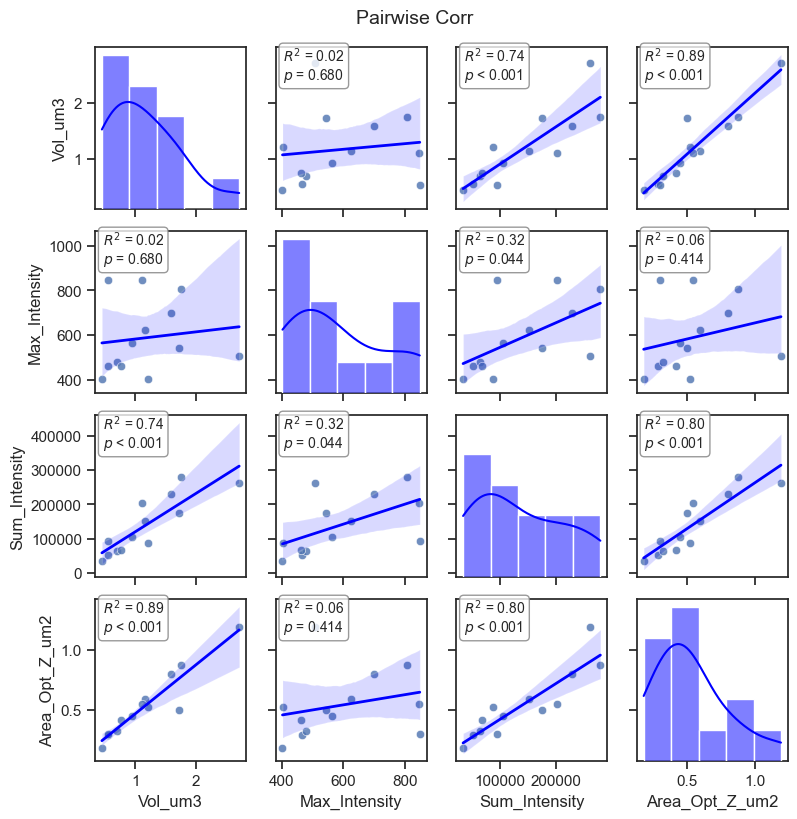

In [6]:

plot_all_cor(df_measure, 
             ['Vol_um3', 'Max_Intensity', 'Sum_Intensity', 'Area_Opt_Z_um2'], 
             mtitle='Pairwise Corr', custsize=2)

## IntSpine vs ground truth

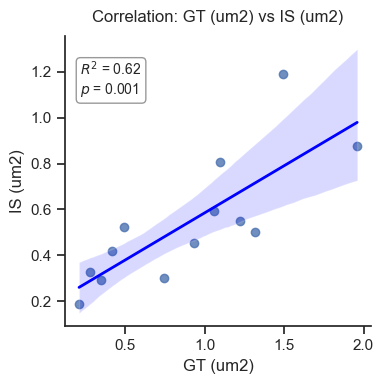

In [17]:
# results = []
# for i,j in finaltoplt.iterrows():

#     xcor = j['Corrected_X']-15
#     ycor = j['Corrected_Y']-15
#     sz = j['Z_Slice']
#     if ycor<1:
#         ycor=1

#     val = get_largest_surface_area_from_tiff(f1, z=sz, x=xcor, y=ycor, width=30, height=30)
#     # print(val)
#     results.append({
#         "Target_ID": j['Target_ID'],
#         "GF_area": val
#     })
# gf_area = pd.DataFrame(results)
# gf_area
tmp1 = pd.read_csv(r"Z:\2026 - E19 Project collab spine and dendrites\Respan\202607013_makingCAREmodel_deconvolution+GaussianFilter\nocare_MS\TEST1\New folder\output_analysis1\bla_spine_results.csv")
tmp2 = pd.read_csv(r"Z:\2026 - E19 Project collab spine and dendrites\Respan\202607013_makingCAREmodel_deconvolution+GaussianFilter\nocare_MS\TEST1\New folder\output_analysis\bla_spine_results.csv")
tmp1 = tmp1[['Target_ID','Corrected_Y','Corrected_X']]
tmp2 = tmp2.drop(columns=['Target_ID'])
tmp = pd.merge(tmp1, tmp2, on=['Corrected_Y','Corrected_X'])
finaltoplt_sub = tmp[['Target_ID','Area_Opt_Z_um2']]
gf_man = pd.read_csv(r"Z:\2026 - E19 Project collab spine and dendrites\Respan\202607013_makingCAREmodel_deconvolution+GaussianFilter\nocare_MS\TEST1\New folder\output_analysis1\validation\areaGF.csv")
gf_man_vs_IS = pd.merge(gf_man, finaltoplt_sub, on='Target_ID') # gf_man_vs_IS = pd.merge(gf_area, finaltoplt_sub, on='Target_ID')

gf_man_vs_IS = gf_man_vs_IS.rename(columns={'surface_um2':'GT (um2)', 'Area_Opt_Z_um2':'IS (um2)'})
plot_single_correlation(gf_man_vs_IS, 'GT (um2)','IS (um2)', fsize=(4,4))


## Manual line characterization
Note the manual line method was done on the max intensity projection

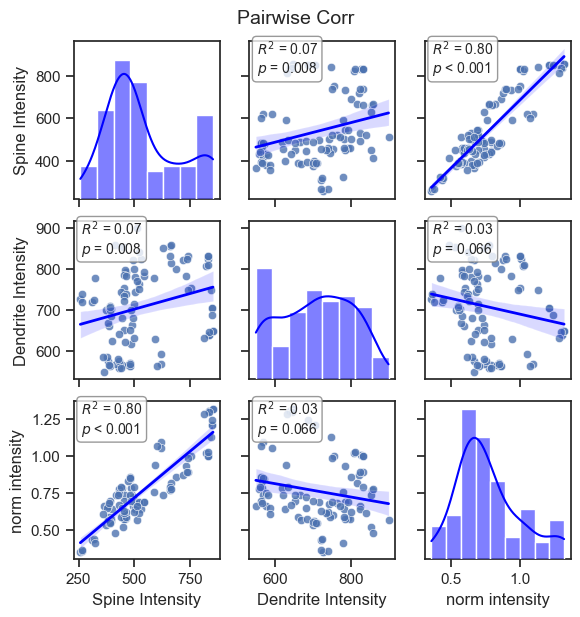

In [26]:
linedata = pd.read_csv(r"Z:\2026 - E19 Project collab spine and dendrites\Respan\202607013_makingCAREmodel_deconvolution+GaussianFilter\nocare_MS\TEST1\New folder\output_analysis1\validation\lineTracing.csv")
linedata = linedata[linedata['Spine Intensity']<2000]
linedata = linedata.rename(columns={'Spine ID': 'Target_ID'})
measure = ['Spine Intensity', 'Dendrite Intensity', 'norm intensity']
pivot_df_l = linedata.pivot_table(
    index=['Target_ID'], 
    columns='Trial', 
    values=measure
).reset_index()

plot_all_cor(linedata, 
             ['Spine Intensity', 'Dendrite Intensity', 'norm intensity'], 
             mtitle='Pairwise Corr', custsize=2)



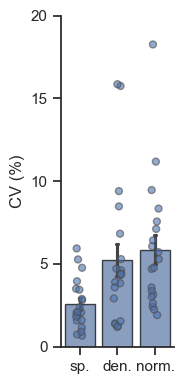

In [9]:

df_long = get_multiple_cv(linedata, measure_cols=['Spine Intensity', 'Dendrite Intensity','norm intensity'])


df_long['type'] = df_long['type'].replace({'Spine Intensity_CV_Percentage': 'sp.', 
                                           'Dendrite Intensity_CV_Percentage': 'den.',
                                           'norm intensity_CV_Percentage': 'norm.'})
df_long
import matplotlib.ticker as ticker
my_ax = plot_multiple_metrics(df_long, fsize=(2.,4), x_col='type', y_cols=['CV'])
my_ax.get_legend().remove()
my_ax.set_xlabel("") 
my_ax.set_ylabel("CV (%)") 
my_ax.set_ylim(0, 20) 
my_ax.set_title('')
my_ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=4))
plt.tight_layout()
plt.show()



## RESPAN comparison

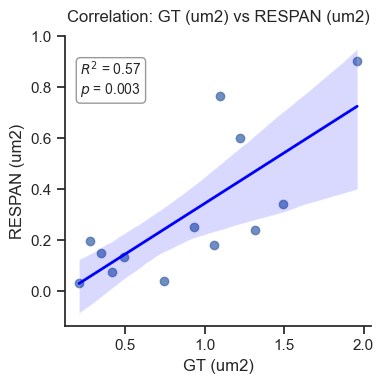

In [24]:
respan = r"Z:\2026 - E19 Project collab spine and dendrites\Respan\202607013_makingCAREmodel_deconvolution+GaussianFilter\nocare_MS\TEST1\Validation_Data\labeling/croppedsegment_detected_spines.csv"
respan = pd.read_csv(respan)
respan = respan.rename(columns={'spine_id': 'Target_ID'})
respan_s  = respan[['Target_ID', 'spine_vol']]

gf_man = pd.read_csv(r"Z:\2026 - E19 Project collab spine and dendrites\Respan\202607013_makingCAREmodel_deconvolution+GaussianFilter\nocare_MS\TEST1\New folder\output_analysis1\validation\areaGF.csv")
gf_man_vs_RESPAN = pd.merge(gf_man, respan_s, on='Target_ID') # gf_man_vs_IS = pd.merge(gf_area, finaltoplt_sub, on='Target_ID')

gf_man_vs_RESPAN = gf_man_vs_RESPAN.rename(columns={'surface_um2':'GT (um2)', 'spine_vol':'RESPAN (um2)'})
plot_single_correlation(gf_man_vs_RESPAN, 'GT (um2)','RESPAN (um2)', fsize=(4,4))

## Comparison 

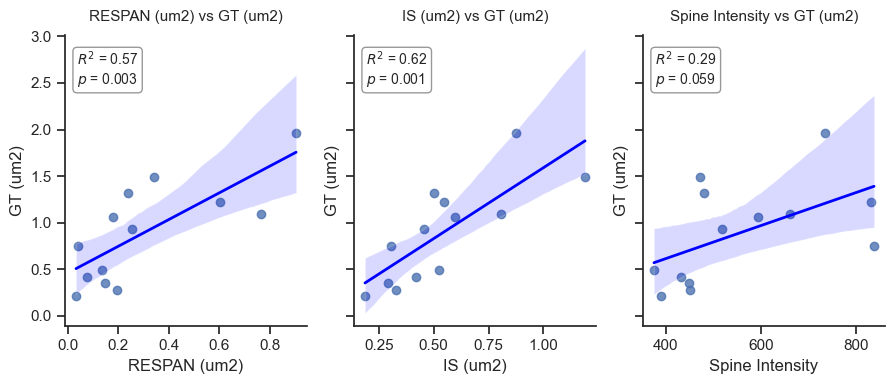

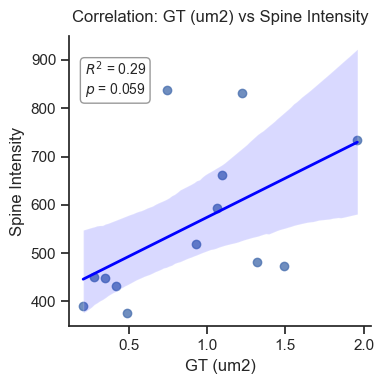

In [59]:
respan_s
gf_man_vs_RESPAN
gf_man_vs_IS
gfm = pd.merge(gf_man_vs_RESPAN, gf_man_vs_IS, on=['Target_ID', 'GT (um2)'])
linedata_s = linedata.groupby('Target_ID')['Spine Intensity'].mean().reset_index()
gfm = pd.merge(gfm, linedata_s, on=['Target_ID'])
gfml = pd.melt(
    gfm,
    id_vars=['Target_ID'],
    value_vars=['GT (um2)', 'RESPAN (um2)', 'IS (um2)', 'Spine Intensity'],
    var_name='method',
    value_name='val'
)
gfml
# for i in ['RESPAN (um2)', 'IS (um2)', 'Spine Intensity']:
plot_multiple_correlations(gfm, x_vars=['RESPAN (um2)', 'IS (um2)', 'Spine Intensity'], y_var='GT (um2)', n_cols=4, fsize=(3,4))
plot_single_correlation(gfm,'GT (um2)','Spine Intensity', fsize=(4,4))

# TO WORK ON

In [37]:
gfm.columns

Index(['Target_ID', 'GT (um2)', 'RESPAN (um2)', 'IS (um2)', 'Spine Intensity'], dtype='object')

In [ ]:
measure = 'Max_Intensity'
final.groupby(['Target_ID'])[measure].var()
pivot_df_int = final.pivot_table(
    index=['Target_ID'], 
    columns='measure_type', 
    values=measure
).reset_index()

combo3 = pd.merge(combo2, pivot_df_int, on='Target_ID')
combo3.head()


,Target_ID,bla_x,blm1_x,blm2_x,spine_vol,line_int_1,line_int_2,line_int_3,bla_y,blm1_y,blm2_y
0,3,2.813357,2.813357,2.813357,0.902648,730.930,751.719,715.897,807.0,807.0,807.0
1,5,1.329696,1.329696,1.329696,0.194497,450.153,453.143,438.095,479.0,479.0,479.0
2,8,4.870886,4.870886,4.870886,0.340006,485.429,499.253,456.812,507.0,507.0,507.0
3,9,2.634898,2.634898,2.634898,0.763555,688.140,661.428,629.803,698.0,698.0,698.0
4,10,1.767096,1.767096,1.802088,0.600550,829.915,830.954,822.638,845.0,845.0,845.0


In [ ]:
respan_gt = r"Z:\Maria\20260722_RESPANcomparisonGT\Retrain_RESPAN\ground_truth_volume_results\Ground_truth_vs_RESPAN_spine_volumes.csv"
respan_gt = pd.read_csv(respan_gt)
respan_gt = respan_gt.rename(columns={'RESPAN_spine_ID':'Target_ID'})
respan_gt = respan_gt[['Target_ID', 'GT_volume_um3']]
respan_gt.dropna()
respan_gt['Target_ID'] = respan_gt['Target_ID'].astype('Int64')
combo3['Target_ID'] = combo3['Target_ID'].astype('Int64')
respan_gt.dtypes
combo4 = pd.merge(combo3, respan_gt, on='Target_ID')
combo4

,Target_ID,bla_x,blm1_x,blm2_x,spine_vol,line_int_1,line_int_2,line_int_3,bla_y,blm1_y,blm2_y,GT_volume_um3
0,3,2.813357,2.813357,2.813357,0.902648,730.930,751.719,715.897,807.0,807.0,807.0,11.459880
1,3,2.813357,2.813357,2.813357,0.902648,730.930,751.719,715.897,807.0,807.0,807.0,NaN
2,5,1.329696,1.329696,1.329696,0.194497,450.153,453.143,438.095,479.0,479.0,479.0,2.543918
3,5,1.329696,1.329696,1.329696,0.194497,450.153,453.143,438.095,479.0,479.0,479.0,NaN
4,8,4.870886,4.870886,4.870886,0.340006,485.429,499.253,456.812,507.0,507.0,507.0,8.492558
5,8,4.870886,4.870886,4.870886,0.340006,485.429,499.253,456.812,507.0,507.0,507.0,NaN
6,9,2.634898,2.634898,2.634898,0.763555,688.140,661.428,629.803,698.0,698.0,698.0,9.706781
7,9,2.634898,2.634898,2.634898,0.763555,688.140,661.428,629.803,698.0,698.0,698.0,NaN
8,10,1.767096,1.767096,1.802088,0.600550,829.915,830.954,822.638,845.0,845.0,845.0,8.978947
9,10,1.767096,1.767096,1.802088,0.600550,829.915,830.954,822.638,845.0,845.0,845.0,NaN


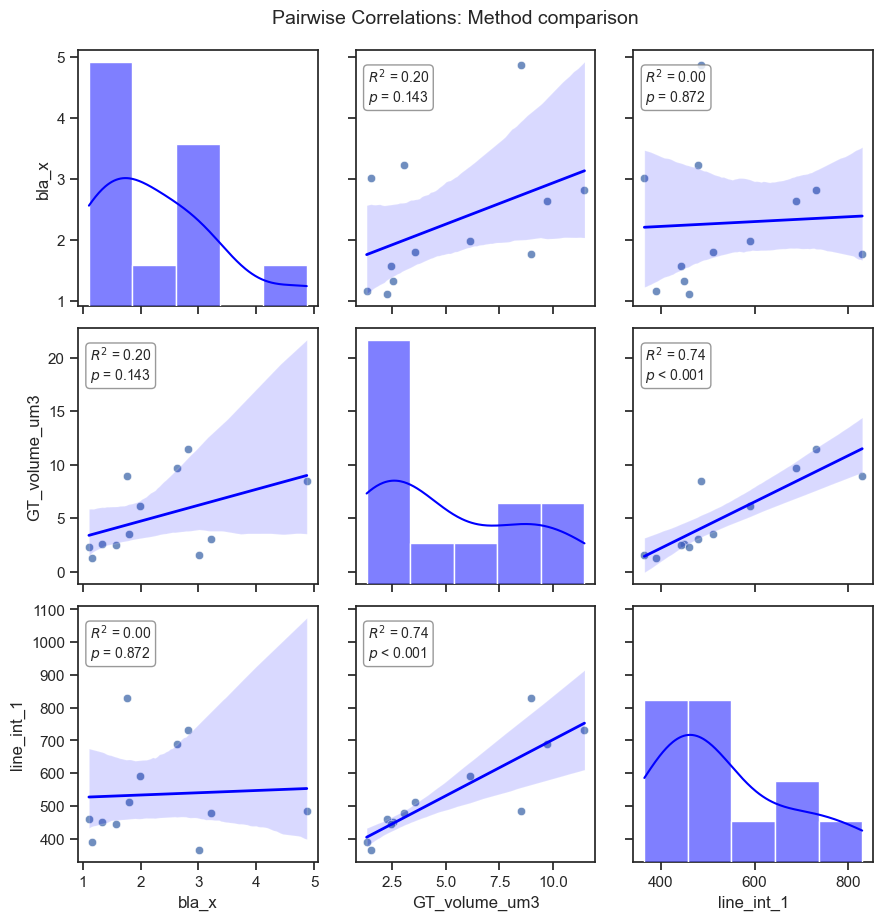

In [ ]:

respan_gt = r"Z:\Maria\20260722_RESPANcomparisonGT\Retrain_RESPAN\ground_truth_volume_results\Ground_truth_vs_RESPAN_spine_volumes.csv"
respan_gt = pd.read_csv(respan_gt)
respan_gt = respan_gt[respan_gt['match_status']!='RESPAN_only'].dropna()
respan_gt = respan_gt.rename(columns={'RESPAN_spine_ID':'Target_ID'})
respan_gt = respan_gt[['Target_ID', 'GT_volume_um3']]
combo4 = pd.merge(combo3, respan_gt, on='Target_ID')
# combo4 = combo4[combo4['bla_x']<2.9]
sns.set_theme(style="ticks")

# Create pairplot with regression lines on the lower/upper triangles
g = sns.PairGrid(combo4, vars=['bla_x', 'GT_volume_um3', 'line_int_1'], height=3, despine=False)

# Map scatter plots with regression lines to the off-diagonal grids
g.map_offdiag(sns.scatterplot, alpha=0.8)
g.map_offdiag(sns.regplot, scatter=False, color='blue', line_kws={'linewidth': 2})

# Map histograms to the diagonal
g.map_diag(sns.histplot, kde=True, color='blue')

# Add R² and p-values to the upper or lower off-diagonal sections
g.map_offdiag(corr_func)

# Adjust layout and show
plt.suptitle("Pairwise Correlations: Method comparison", y=1.02, fontsize=14)
plt.show()

## plotting tool

In [16]:
f1=r"Z:\Maria\20260722_RESPANcomparisonGT\Retrain_RESPAN\groundtruth\croppedsegment.tif" ## Maria ground truth
f2=r"Z:\2026 - E19 Project collab spine and dendrites\Respan\202607013_makingCAREmodel_deconvolution+GaussianFilter\nocare_MS\TEST1\New folder\output_analysis1\bla_segmentation_mask.tif" ## tool mask segmentation
f3=r"Z:\2026 - E19 Project collab spine and dendrites\Respan\202607013_makingCAREmodel_deconvolution+GaussianFilter\nocare_MS\TEST1\New folder\bla.tif"
f4=r"Z:\Maria\20260722_RESPANcomparisonGT\Retrain_RESPAN\labelsTr\croppedsegment_0000.tif"

In [15]:
finaltoplt = final[final['measure_type']=='bla']

In [ ]:
import numpy as np
from skimage import measure
import tifffile


# --- Example Usage ---
# path = "path/to/your/image_stack.tif"
# # This will crop a 100x100 box starting at pixel coordinates x=15, y=30
# area = get_largest_surface_area_from_tiff(path, z=5, x=15, y=30, width=100, height=100)
# print(f"Largest surface area: {area} pixels")

## Tile extraction

0 19
149 1


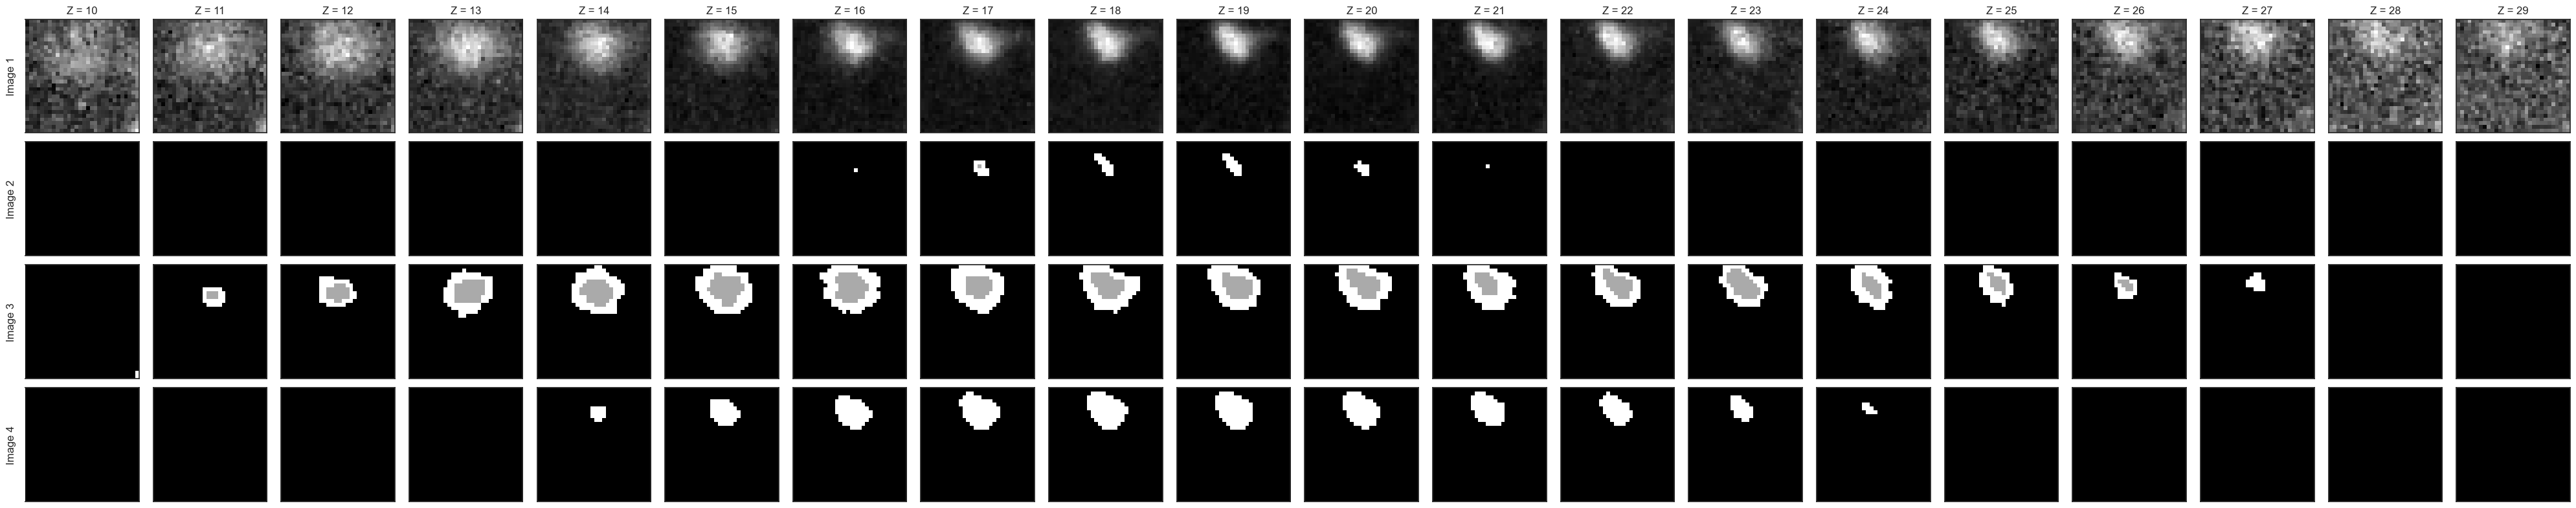

1 21
127 124


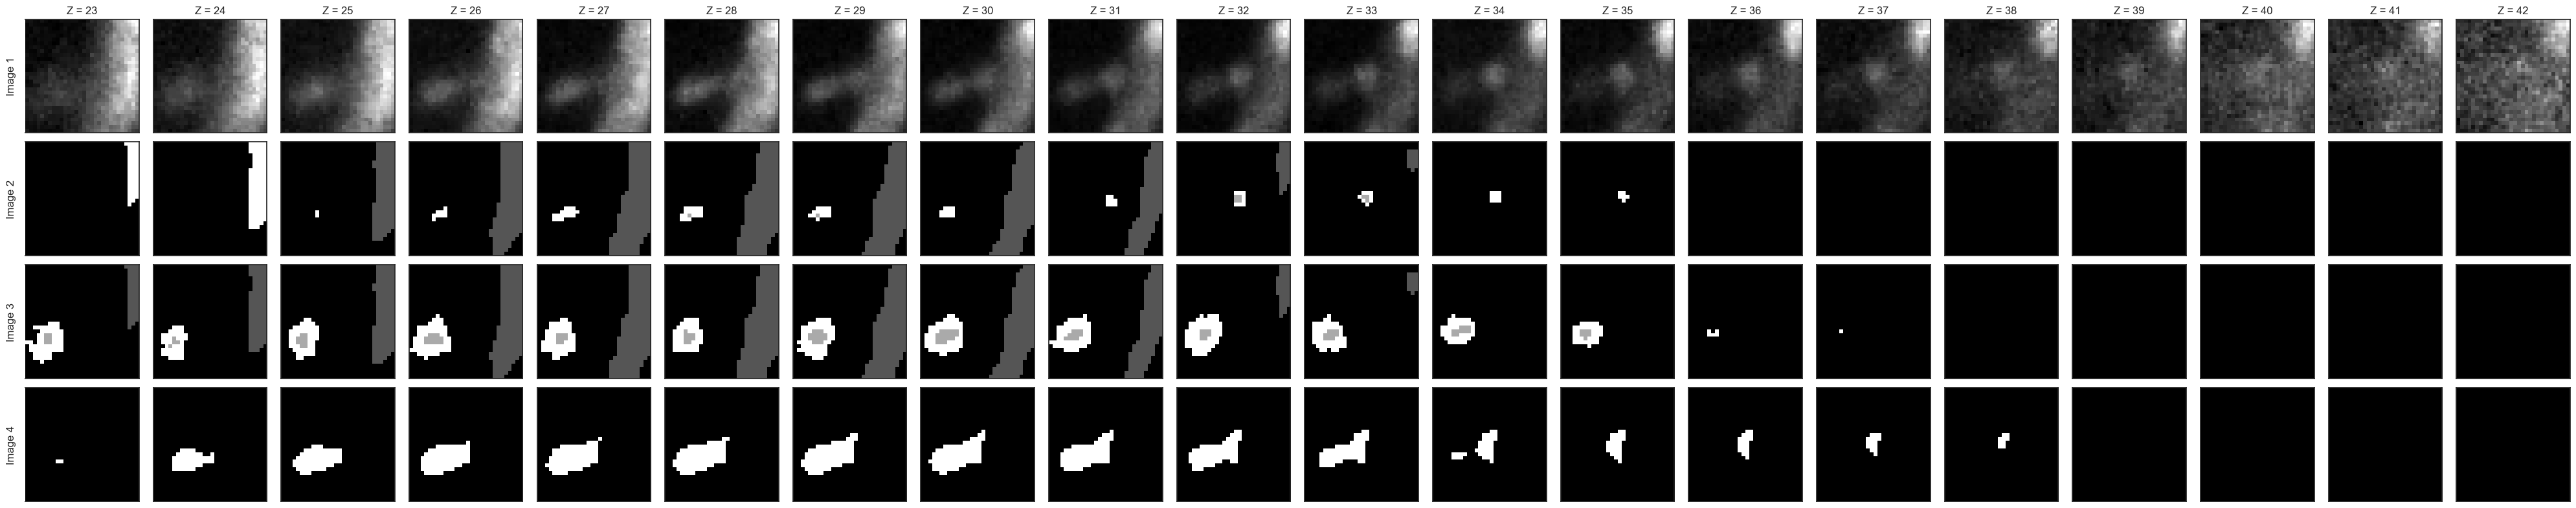

2 22
109 161


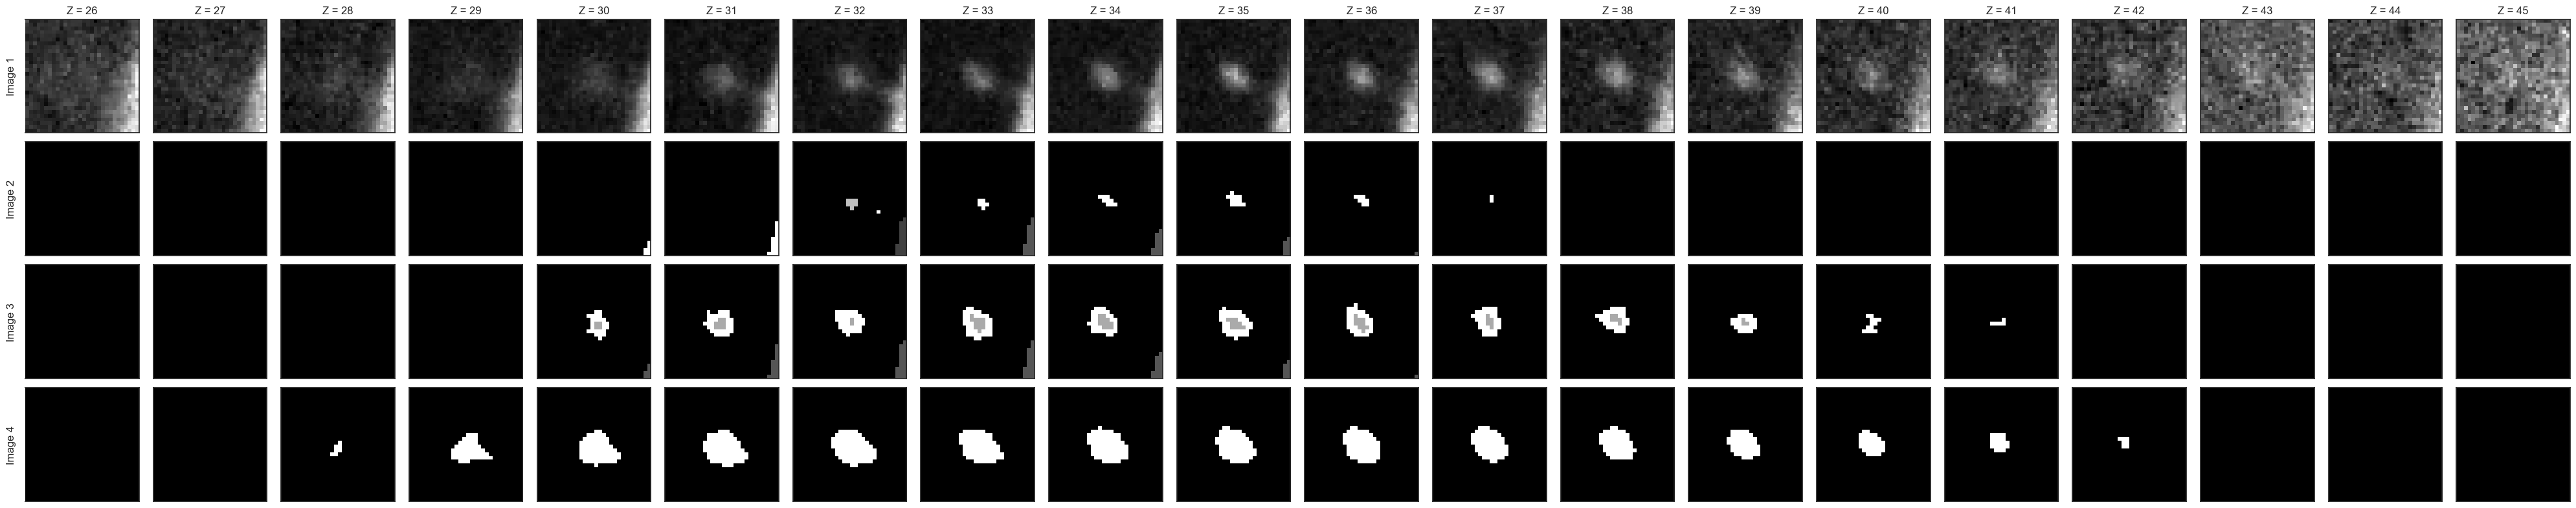

3 3
134 195


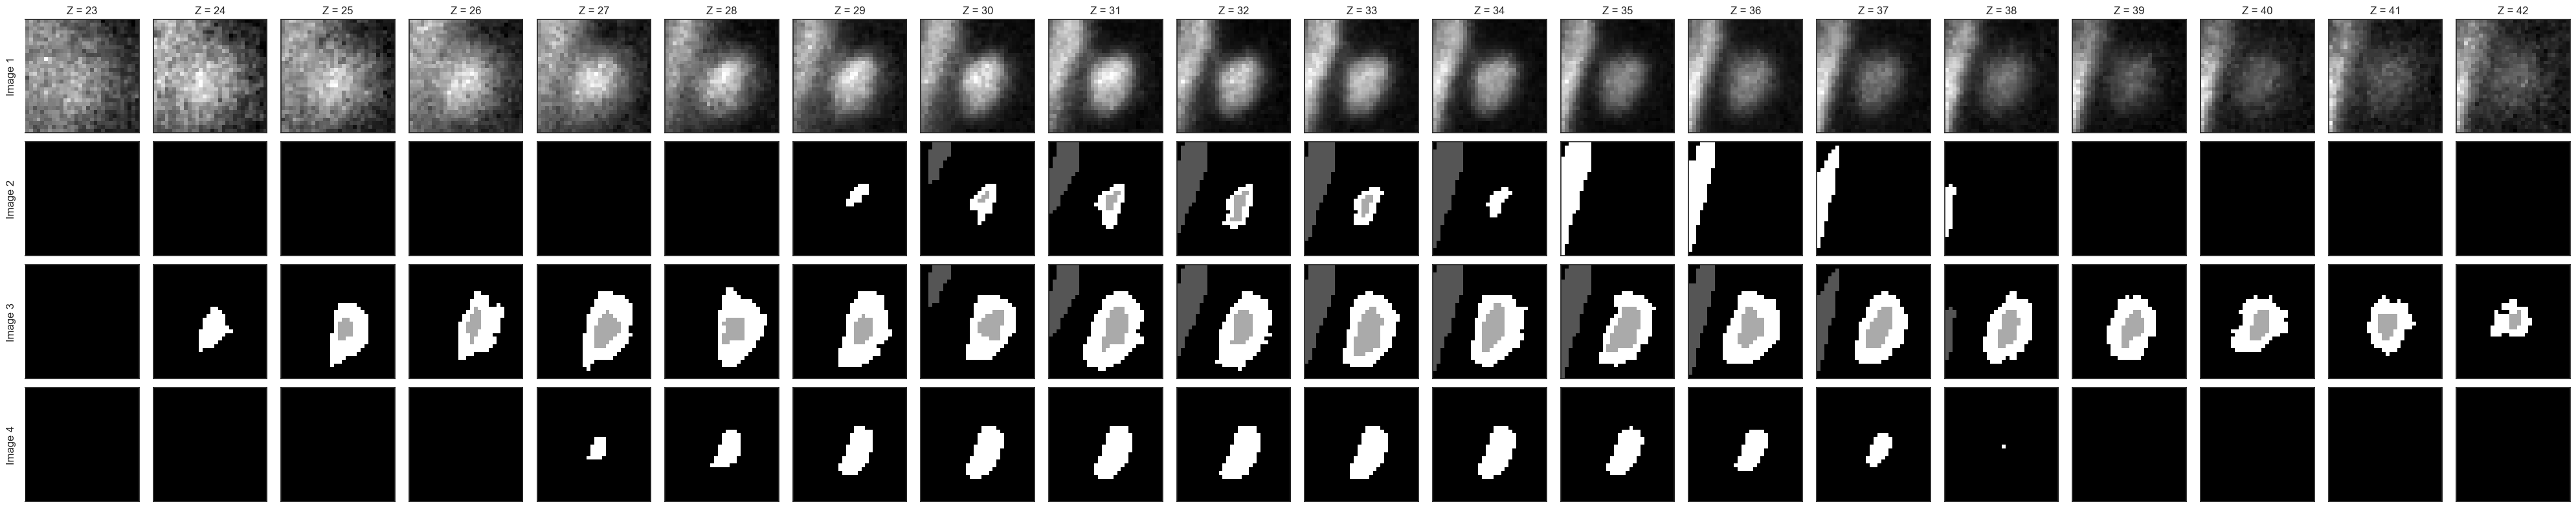

4 23
105 199


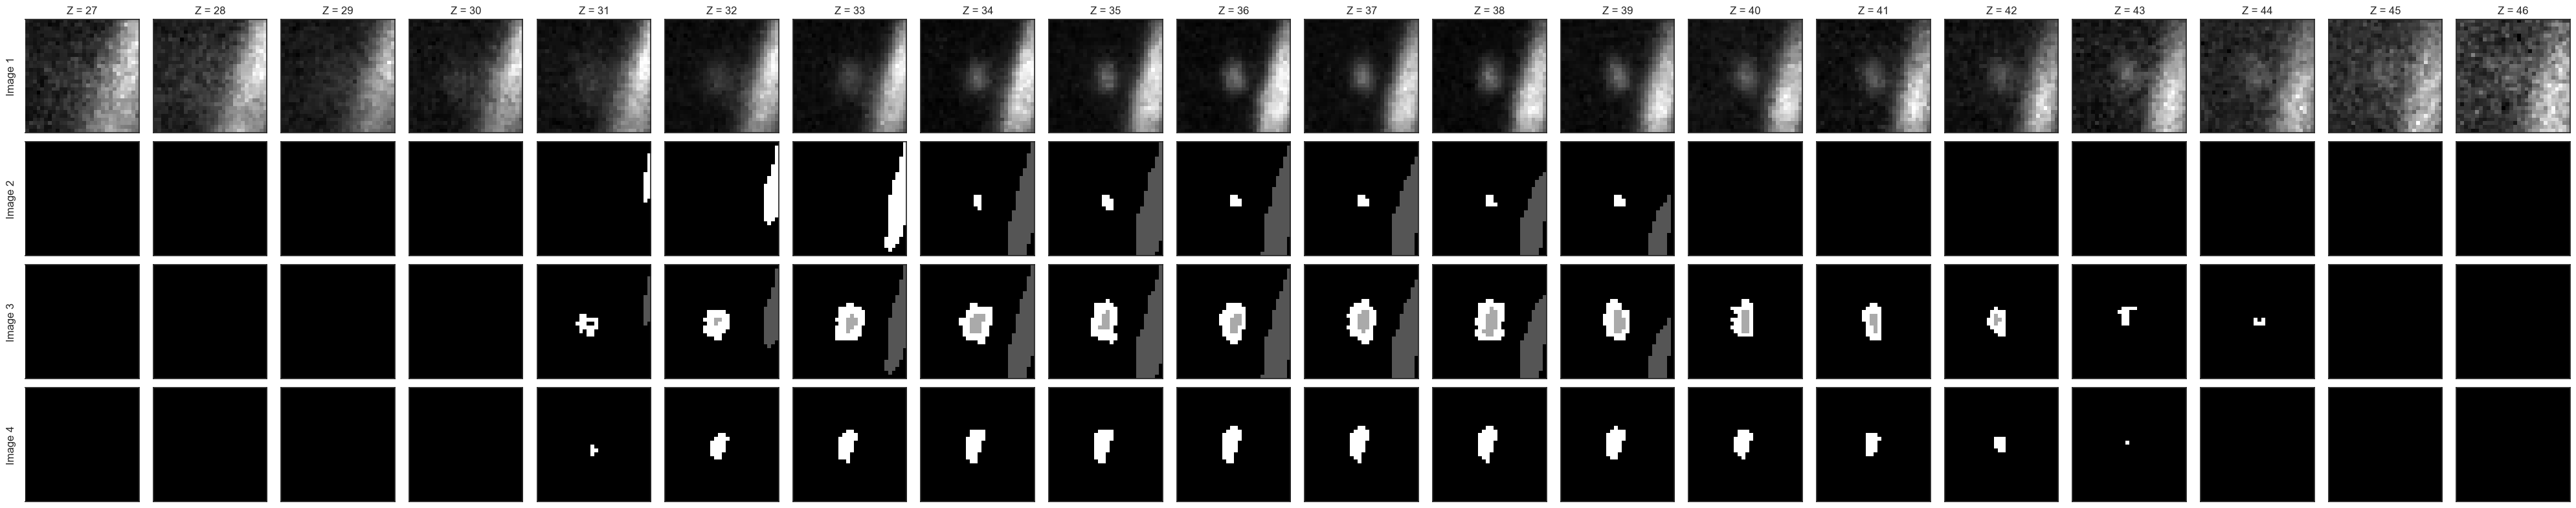

5 5
126 239


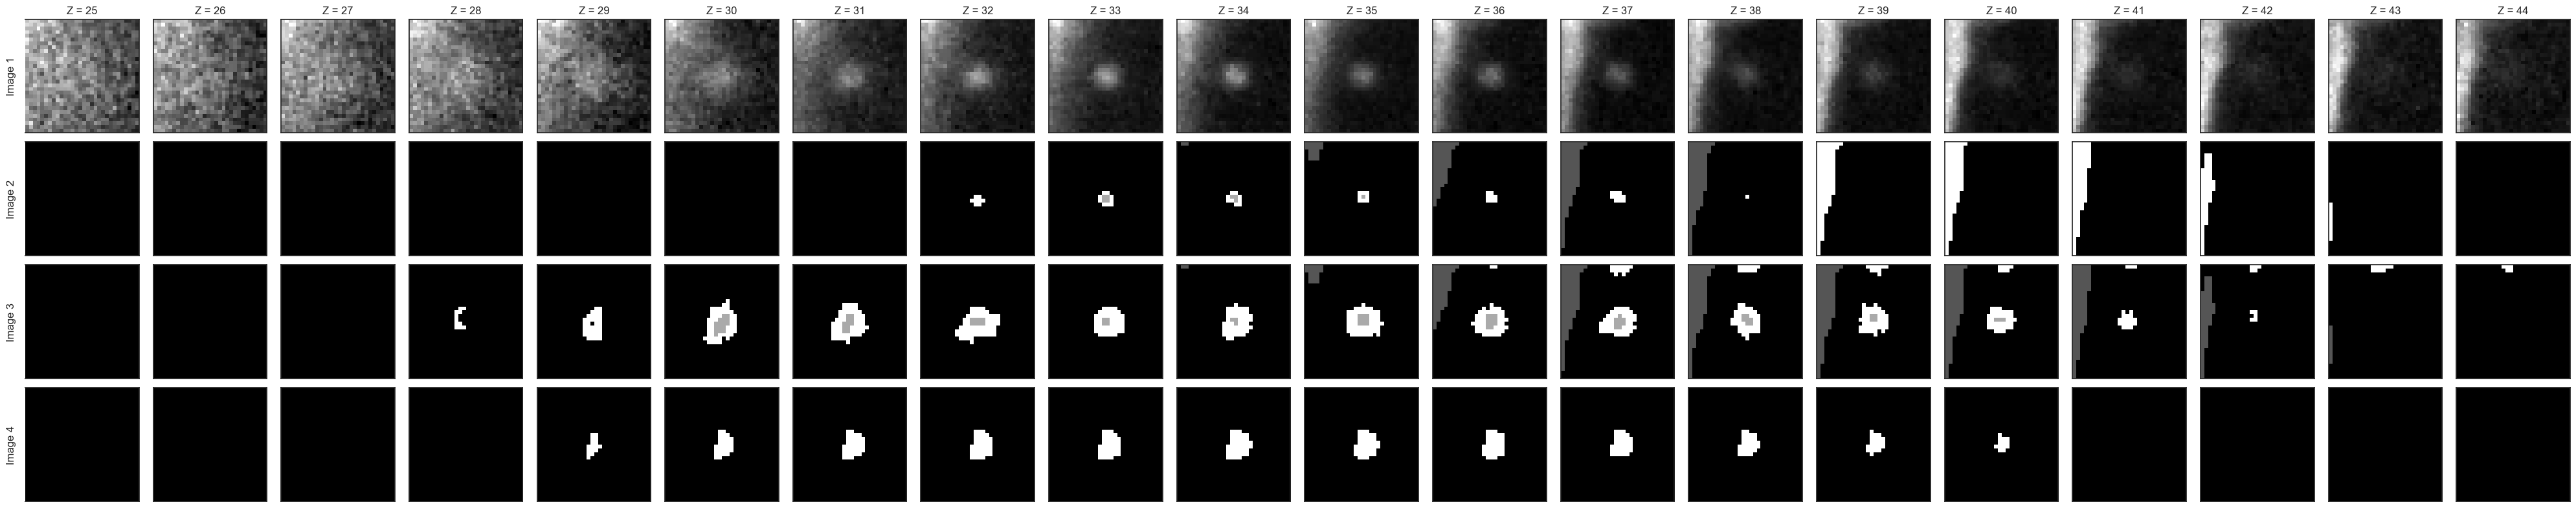

6 9
115 309


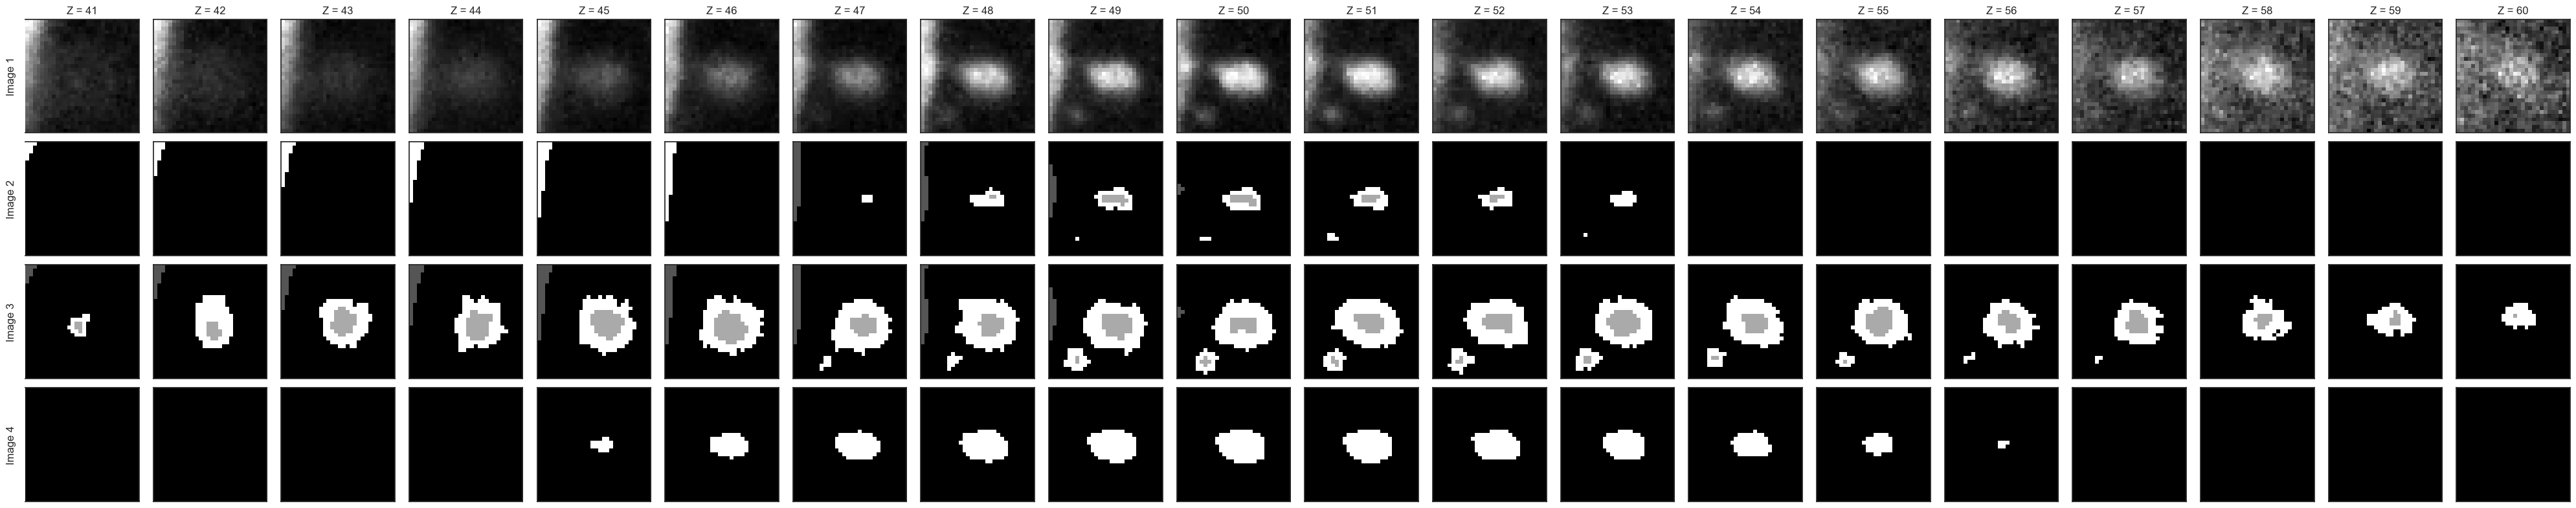

7 10
82 322


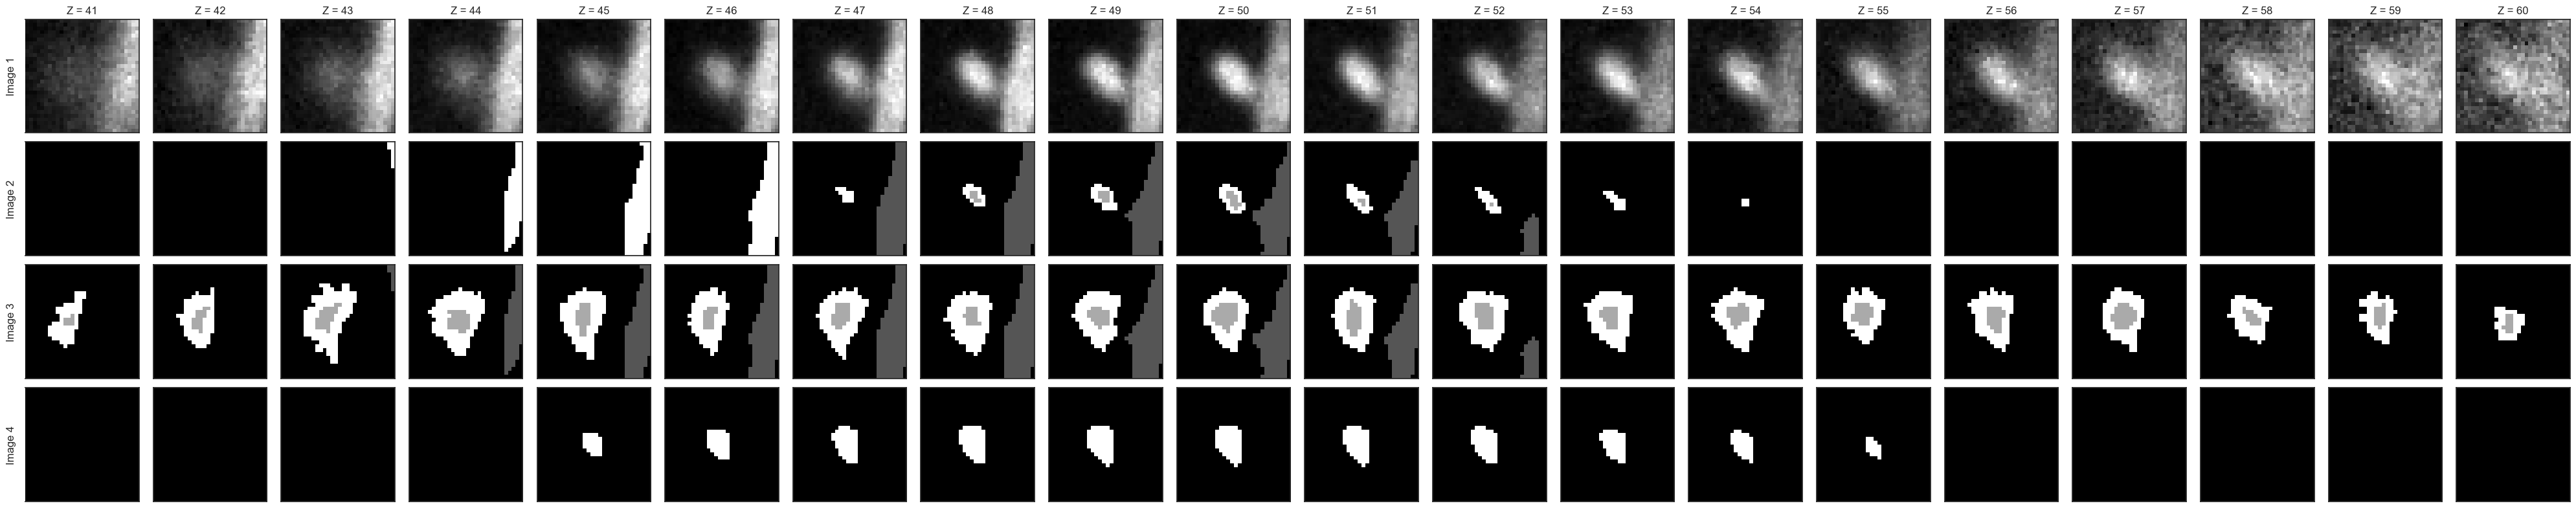

8 8
64 355


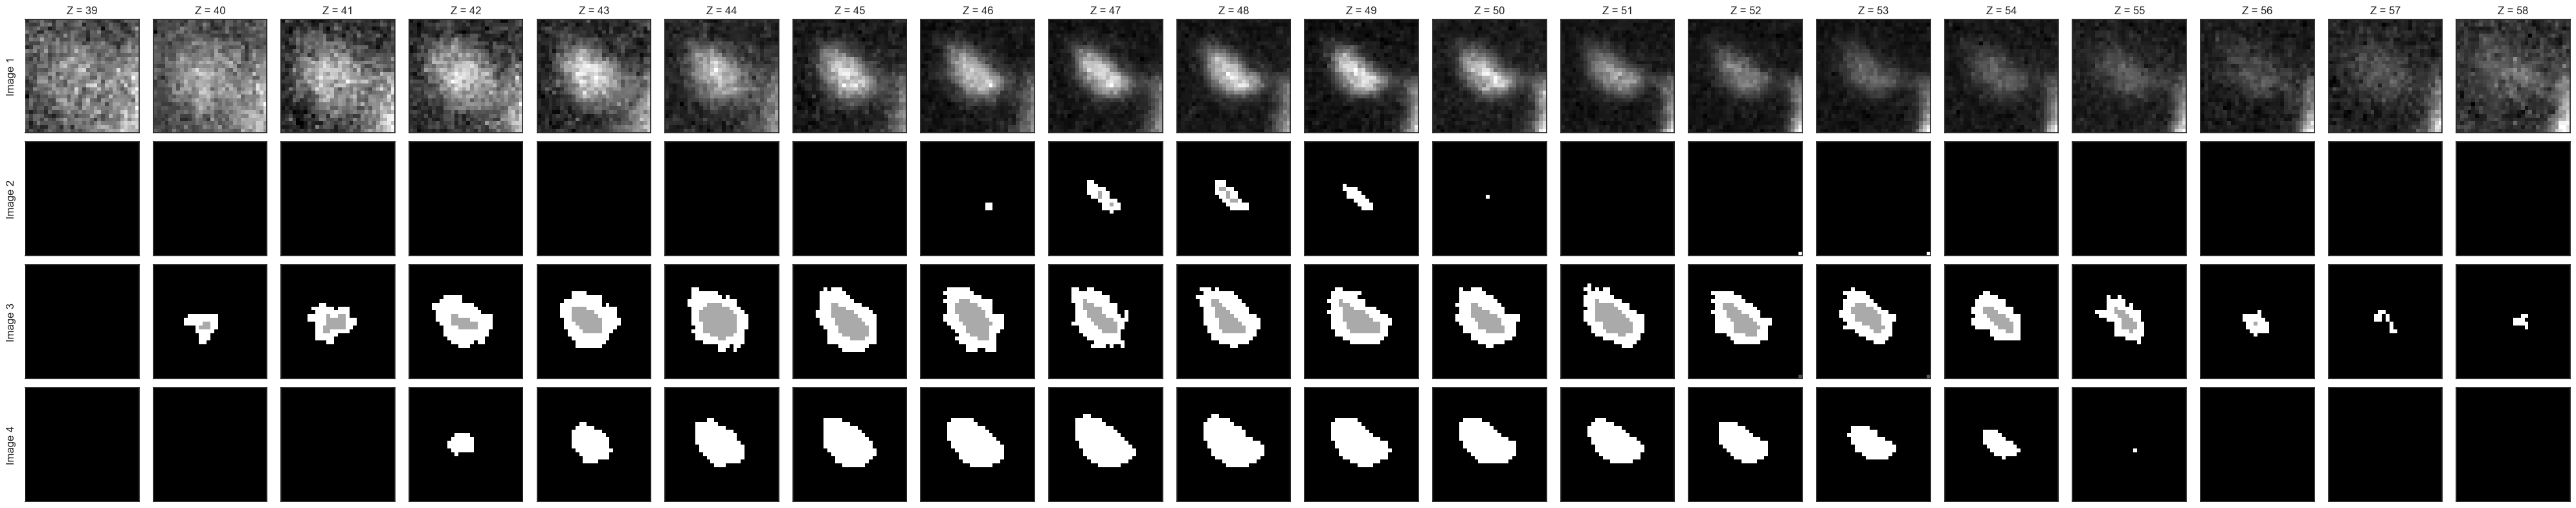

9 28
99 363


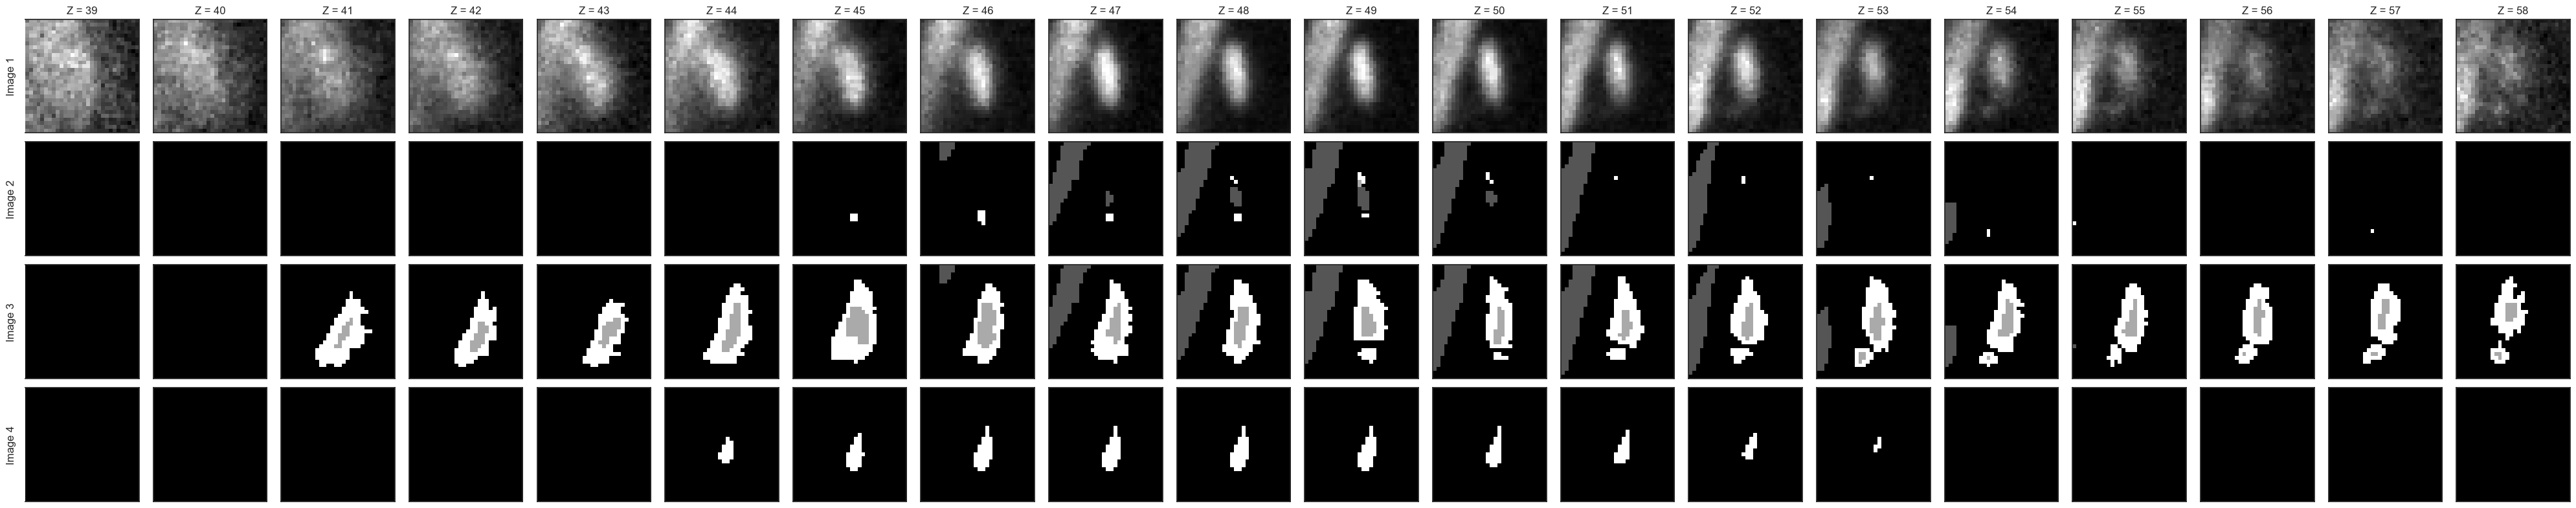

10 31
62 402


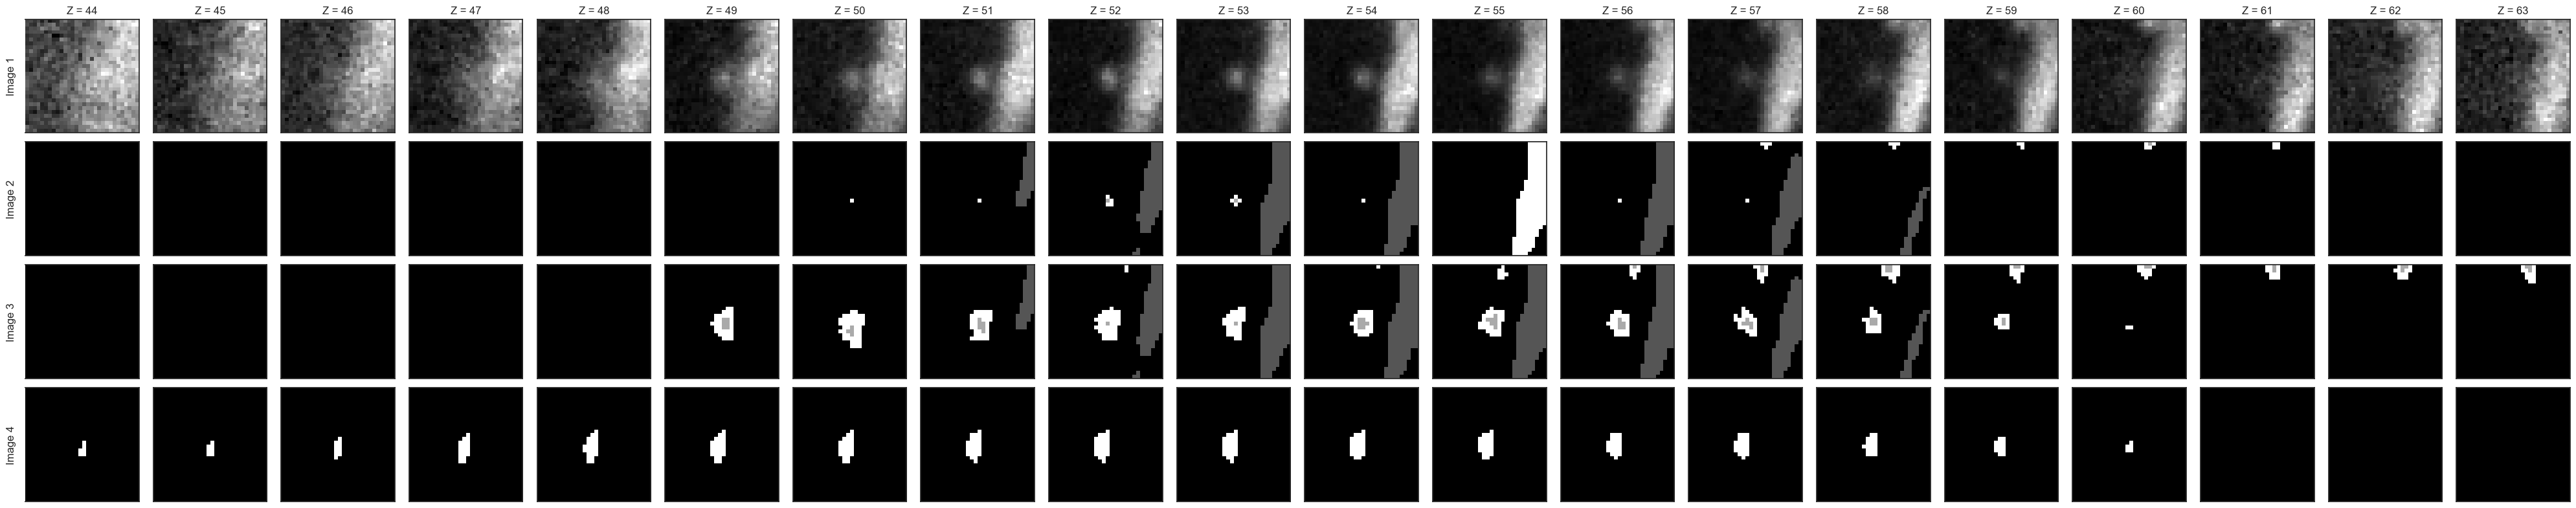

11 32
88 426


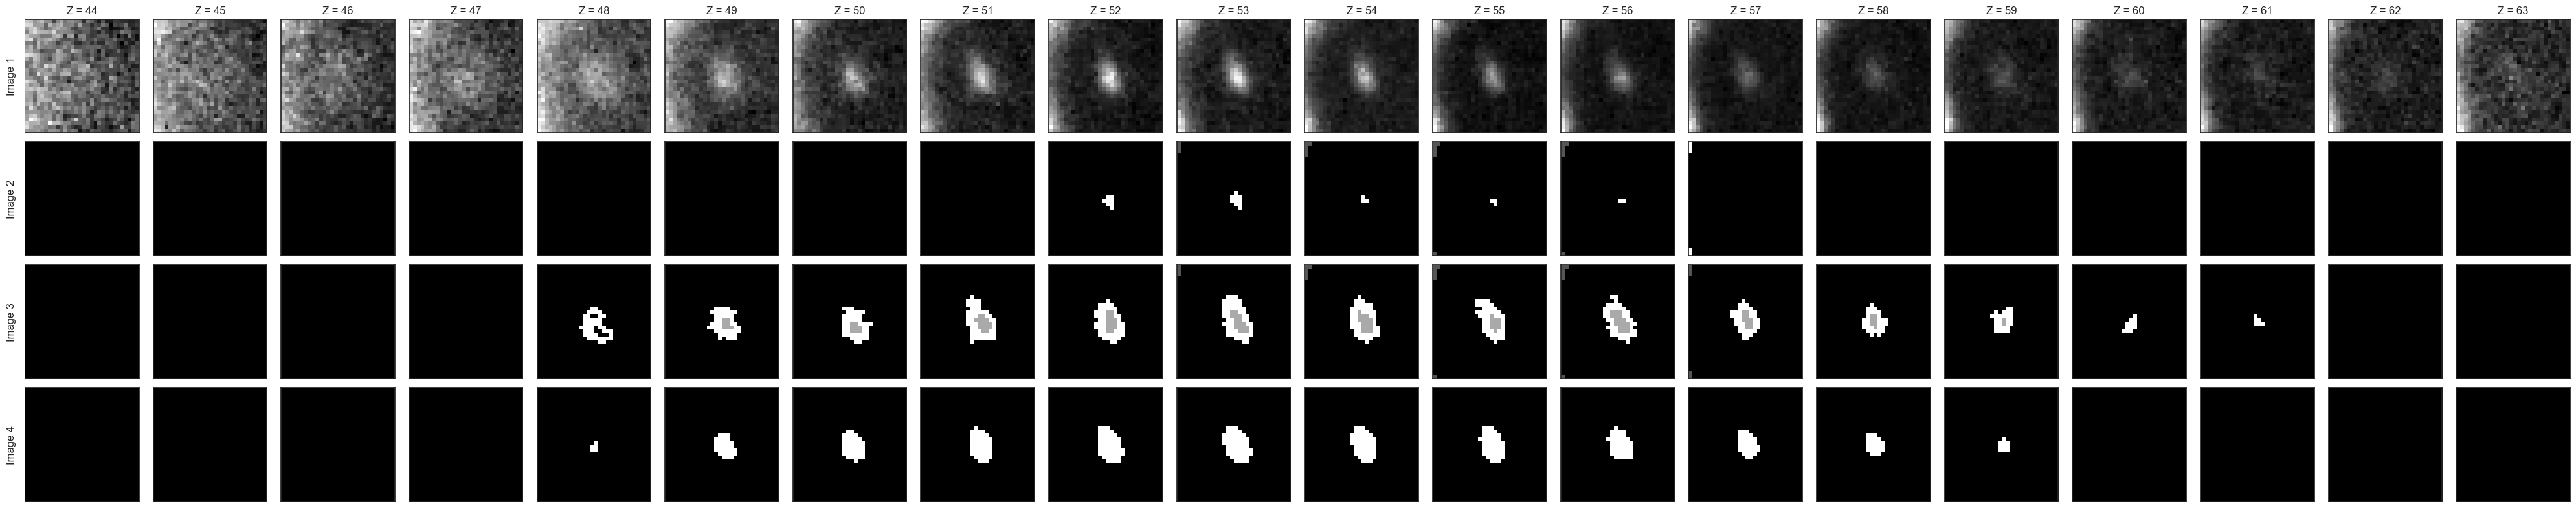

12 17
59 503


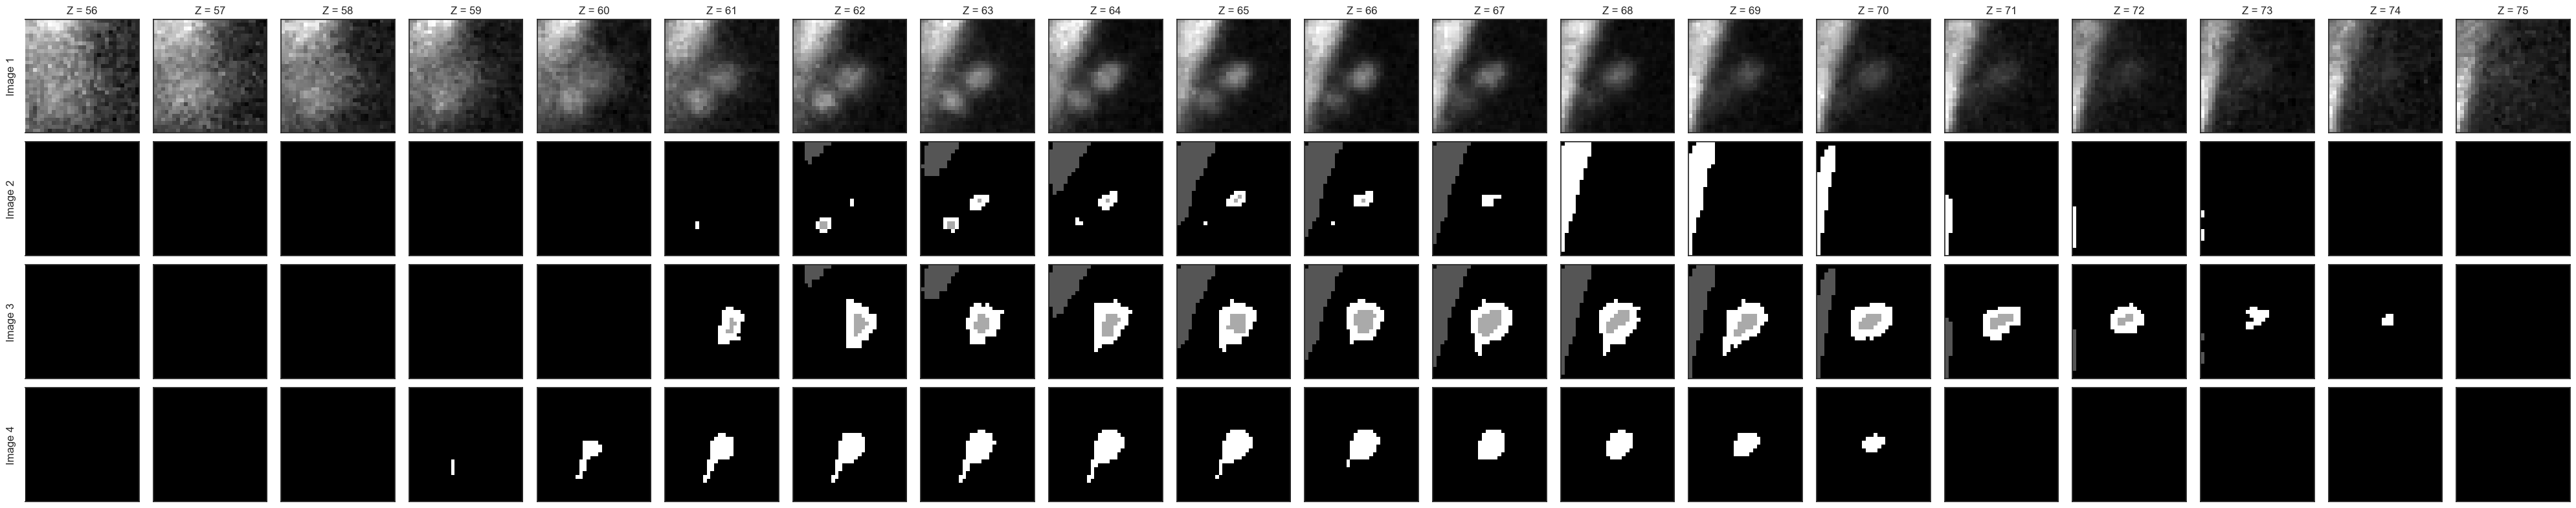

In [ ]:
# extract_and_plot_tiles([f1,f2,f3], start_z=39, num_tiles=20, x=62, y=354)

for i,j in finaltoplt.iterrows():
    print(i,j['Target_ID'])
    xcor = j['Corrected_X']-15
    ycor = j['Corrected_Y']-15
    sz = j['Z_Slice']-10
    
    if ycor<1:
        ycor=1
    print(xcor, ycor)
    extract_and_plot_tiles([f3,f4,f1,f2], start_z=j['Z_Slice']-10, num_tiles=20, x=xcor, y=ycor)

0 19
149 1


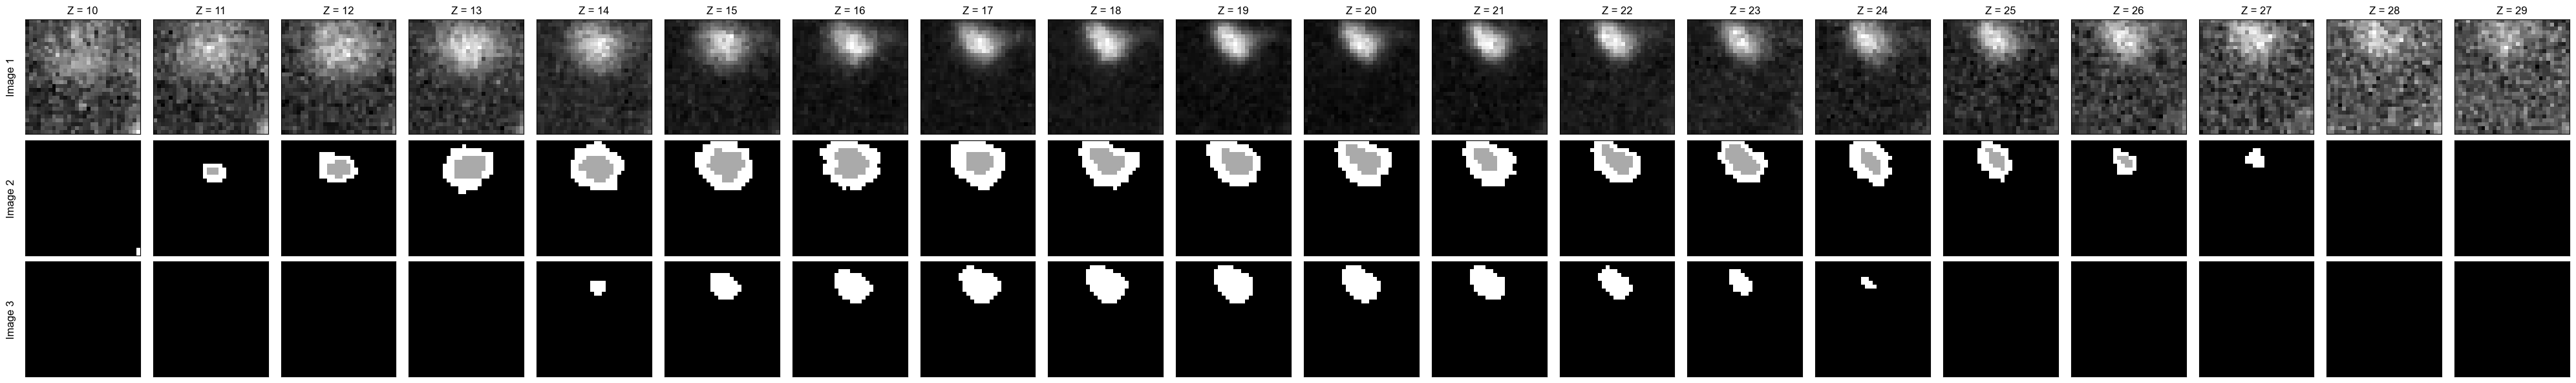

1 21
127 124


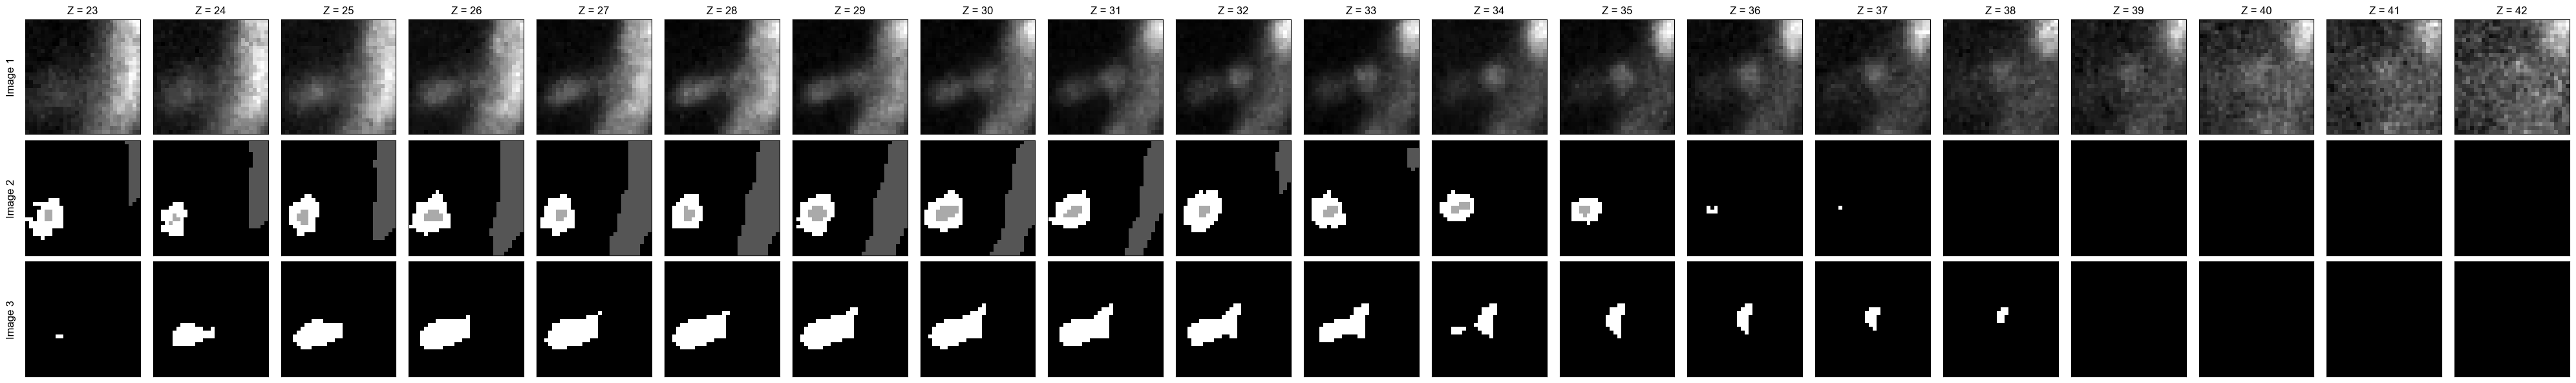

2 22
109 161


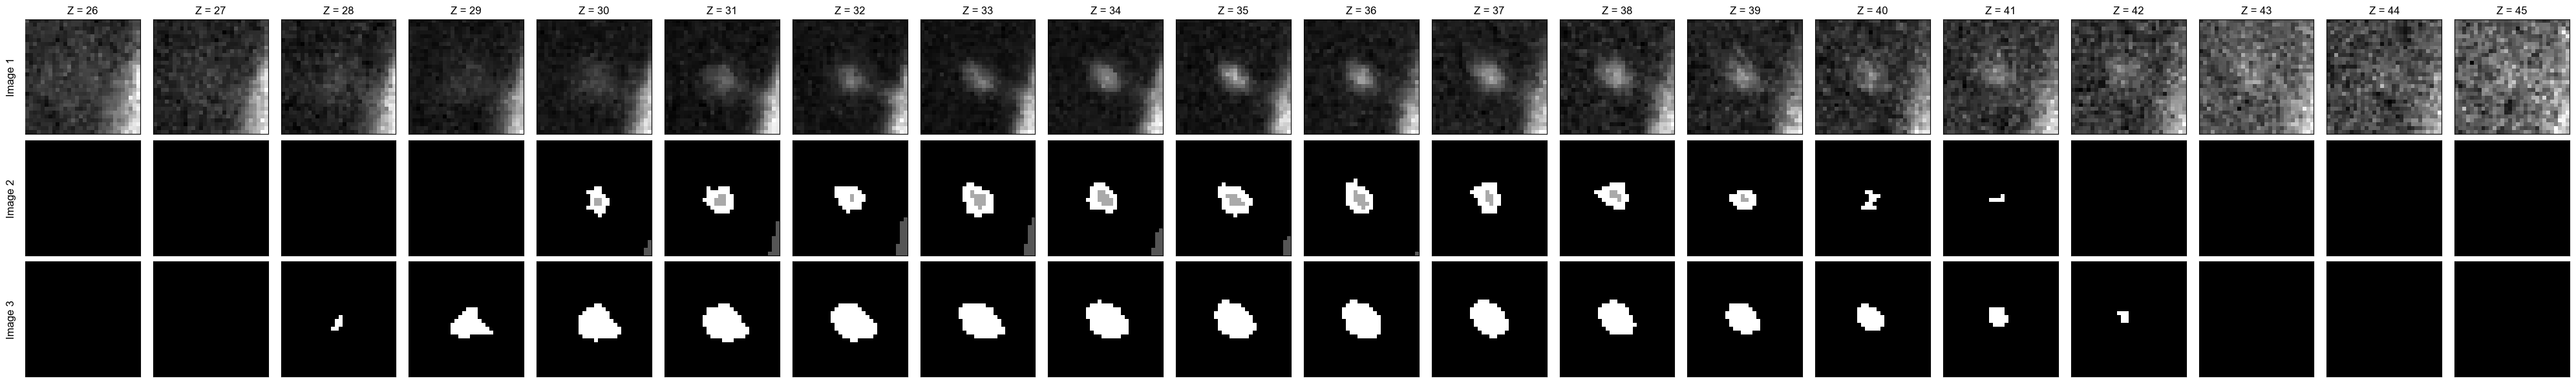

3 3
134 195


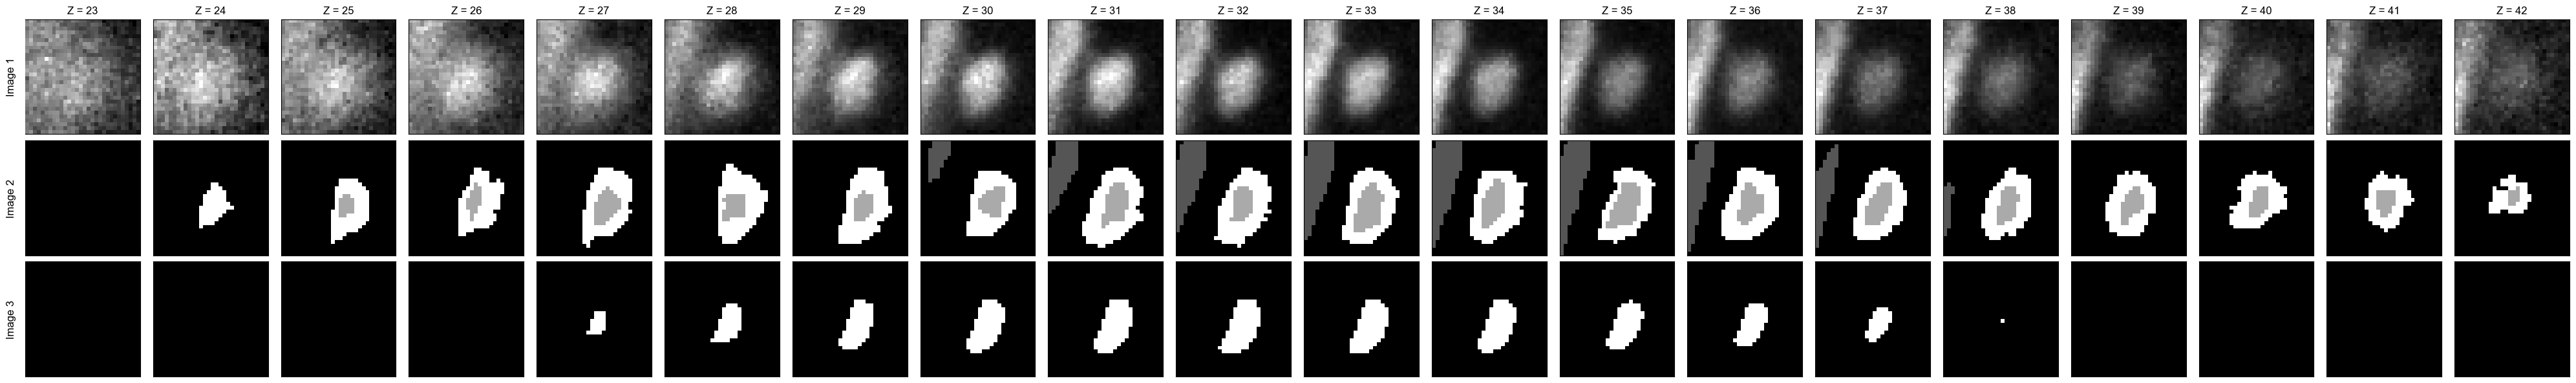

4 23
105 199


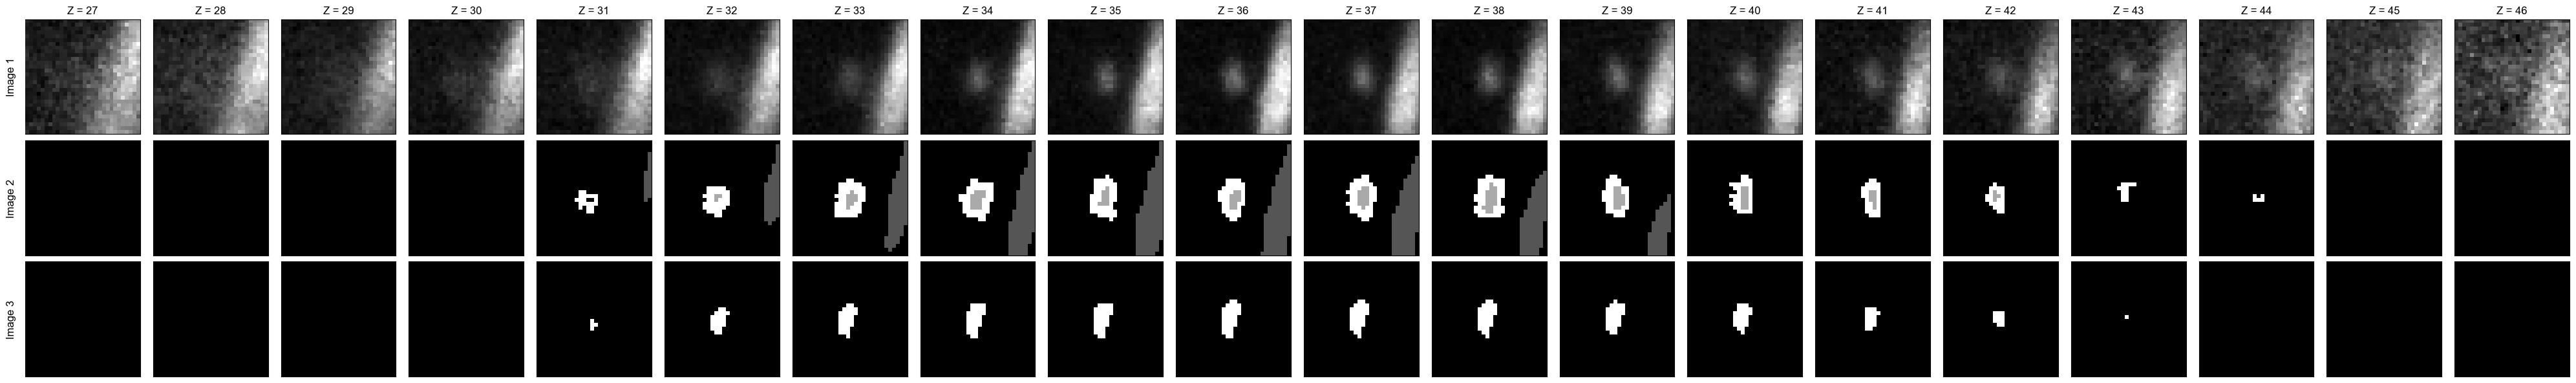

5 5
126 239


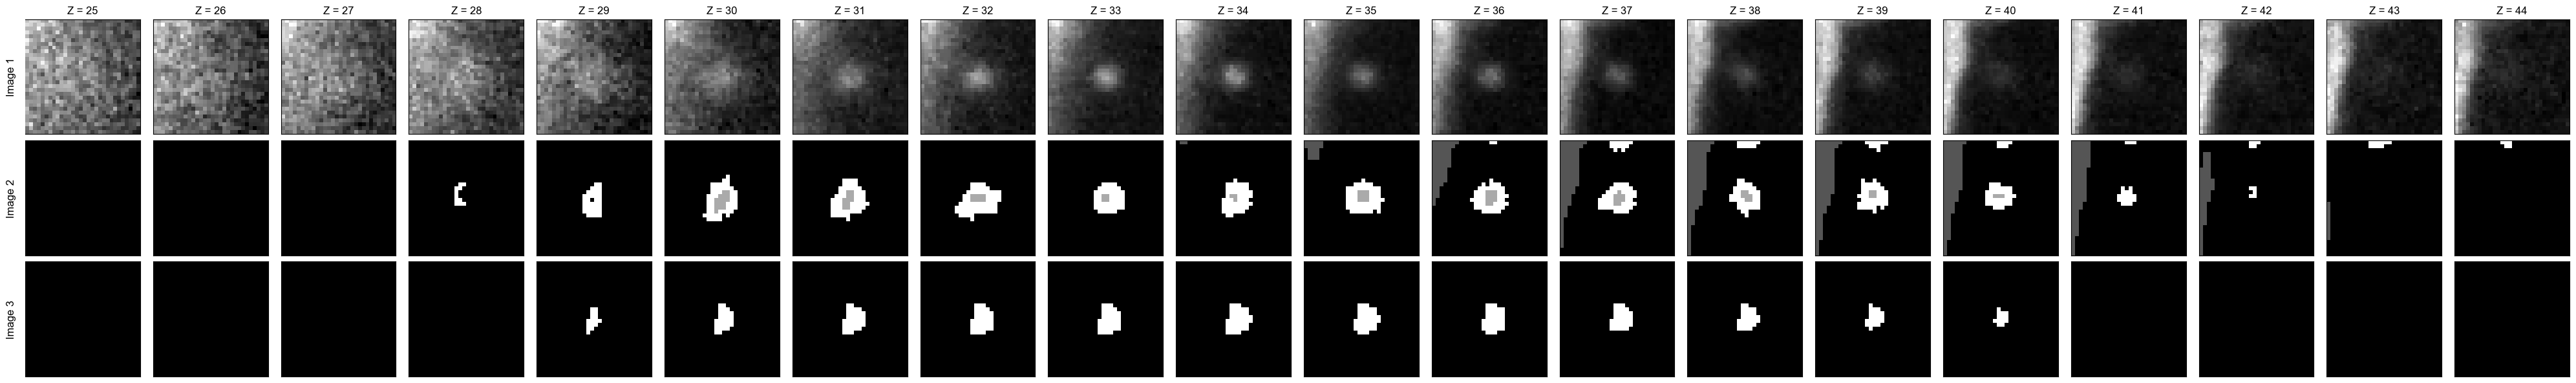

6 9
115 309


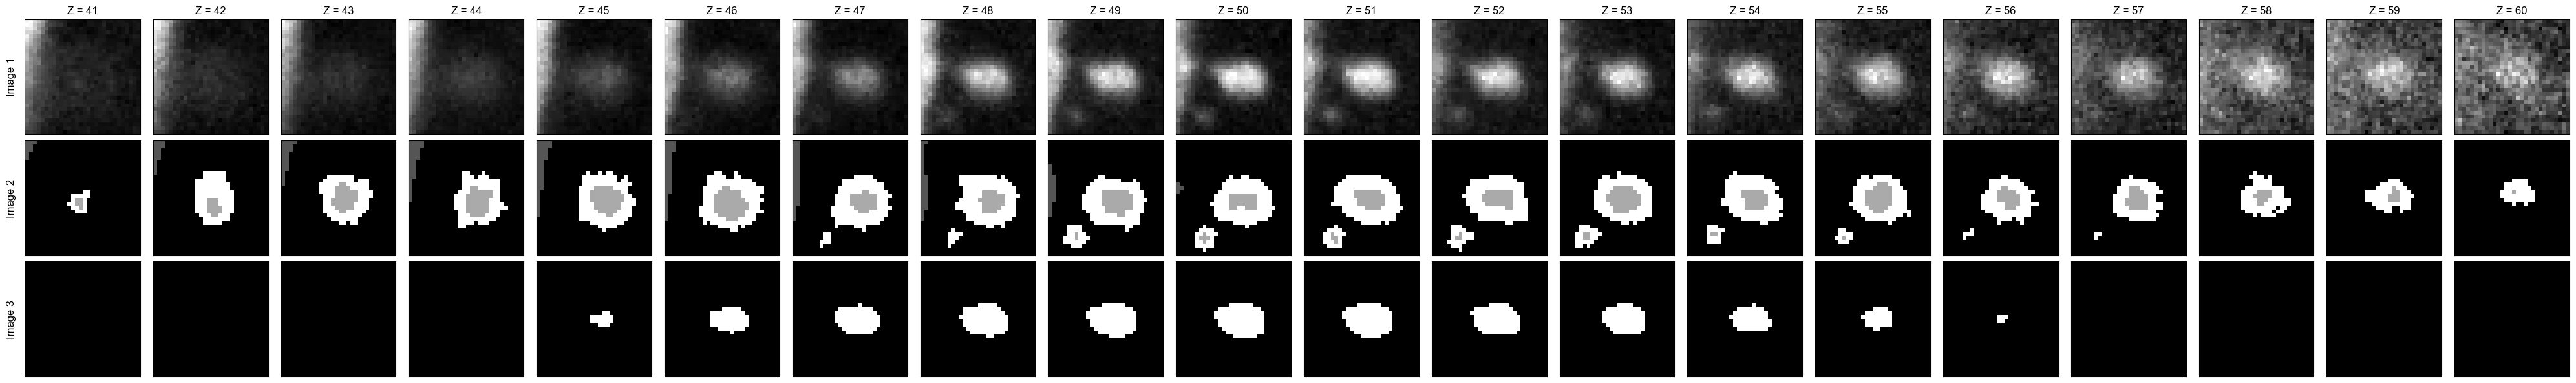

7 10
82 322


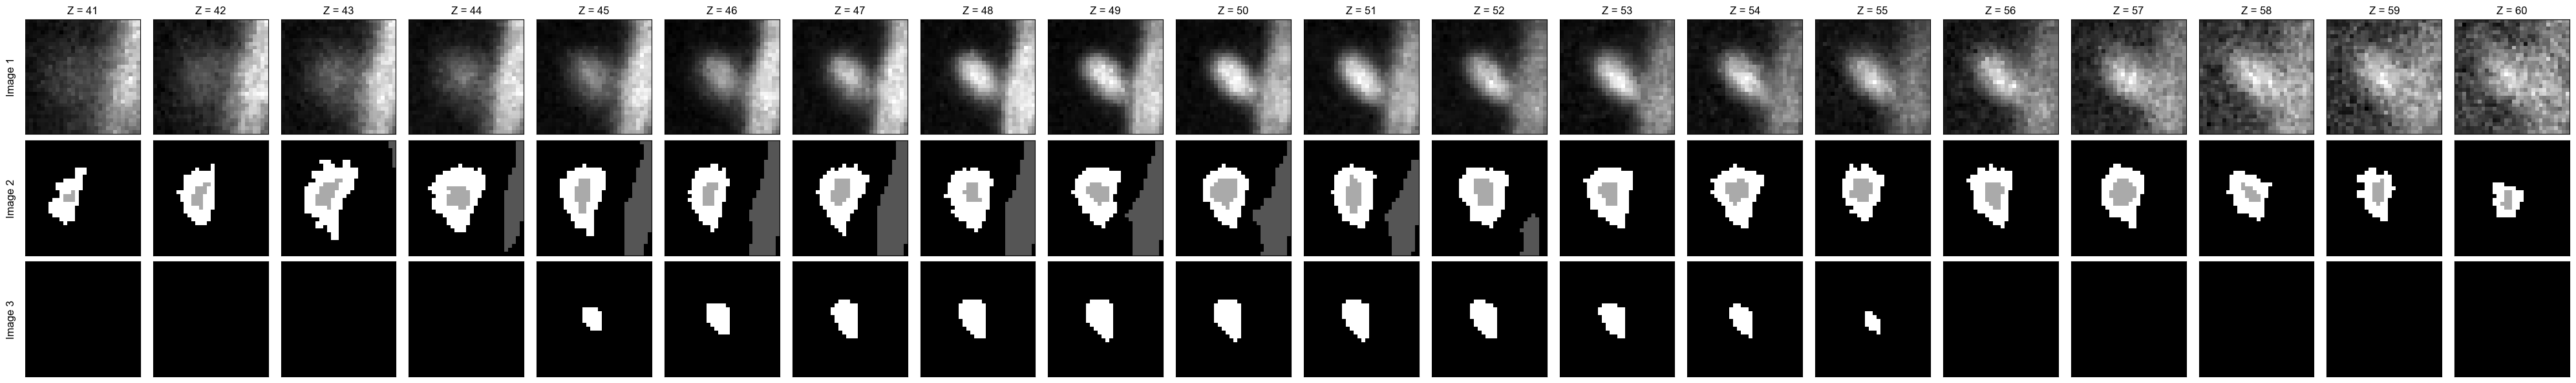

8 8
64 355


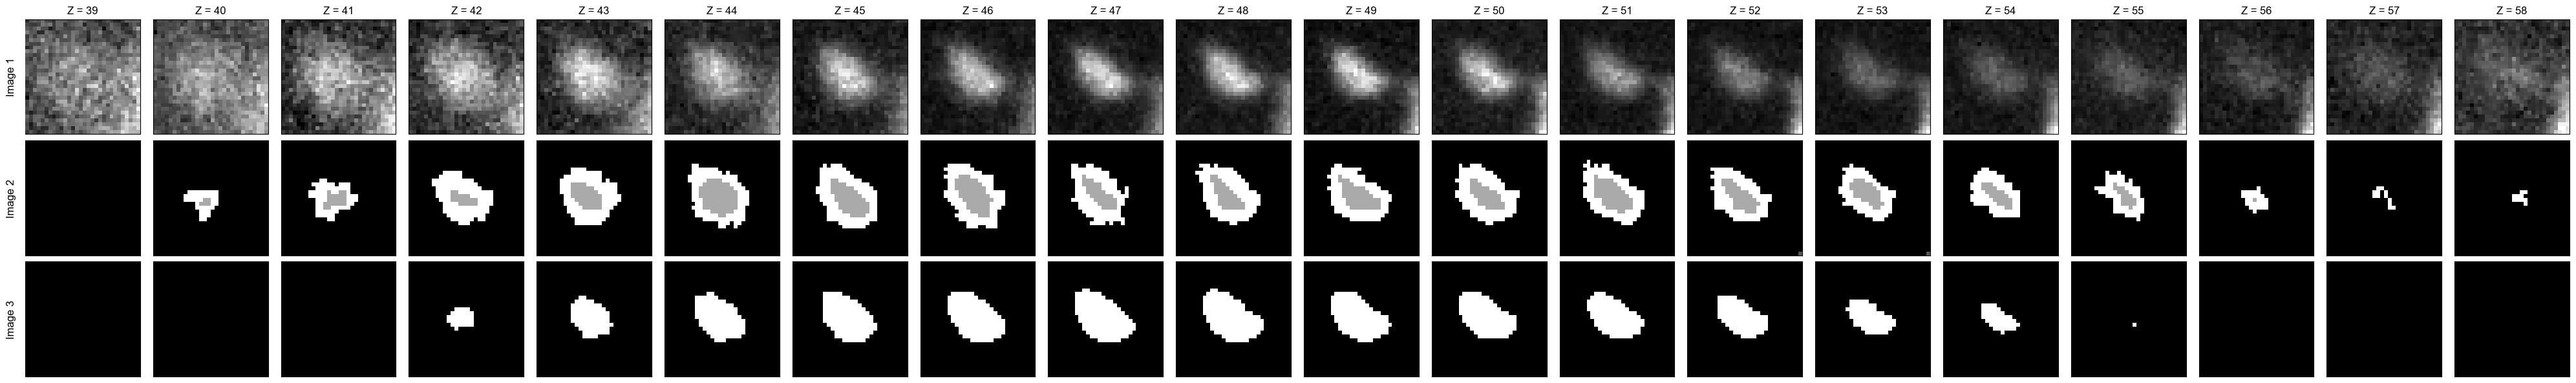

9 28
99 363


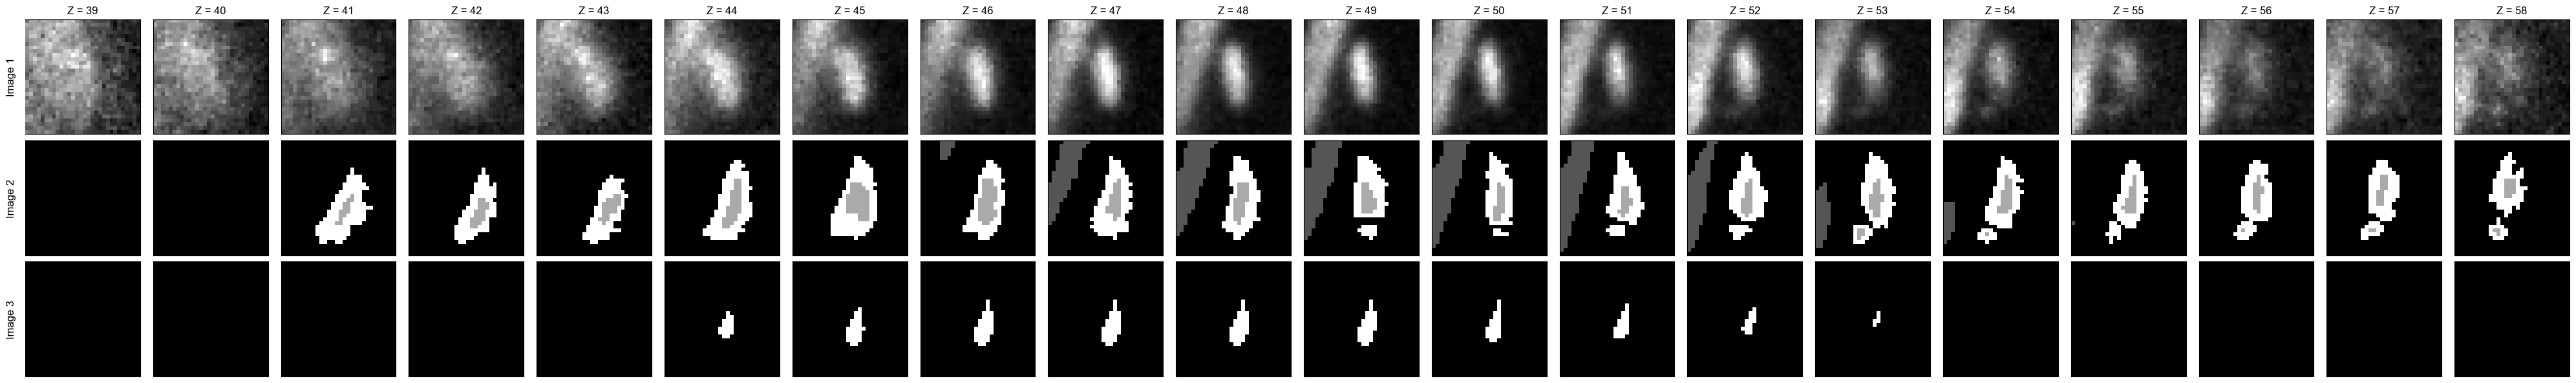

10 31
62 402


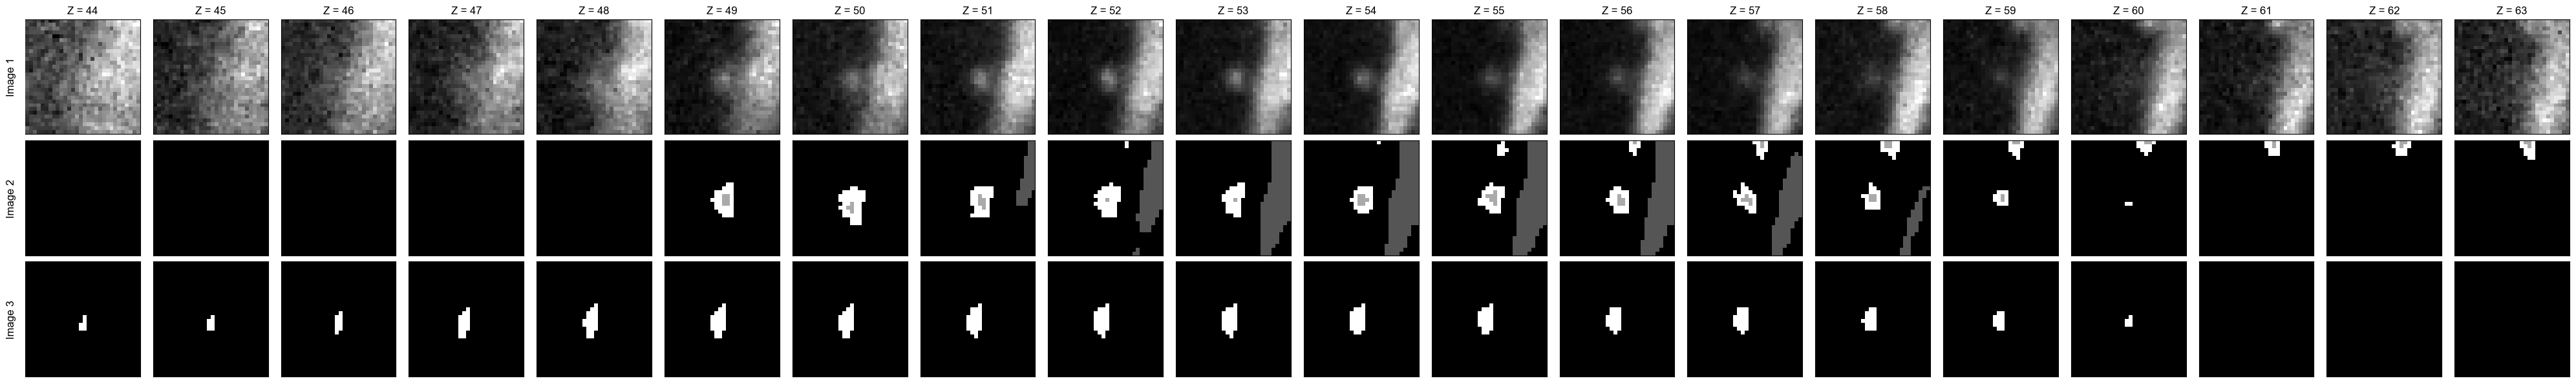

11 32
88 426


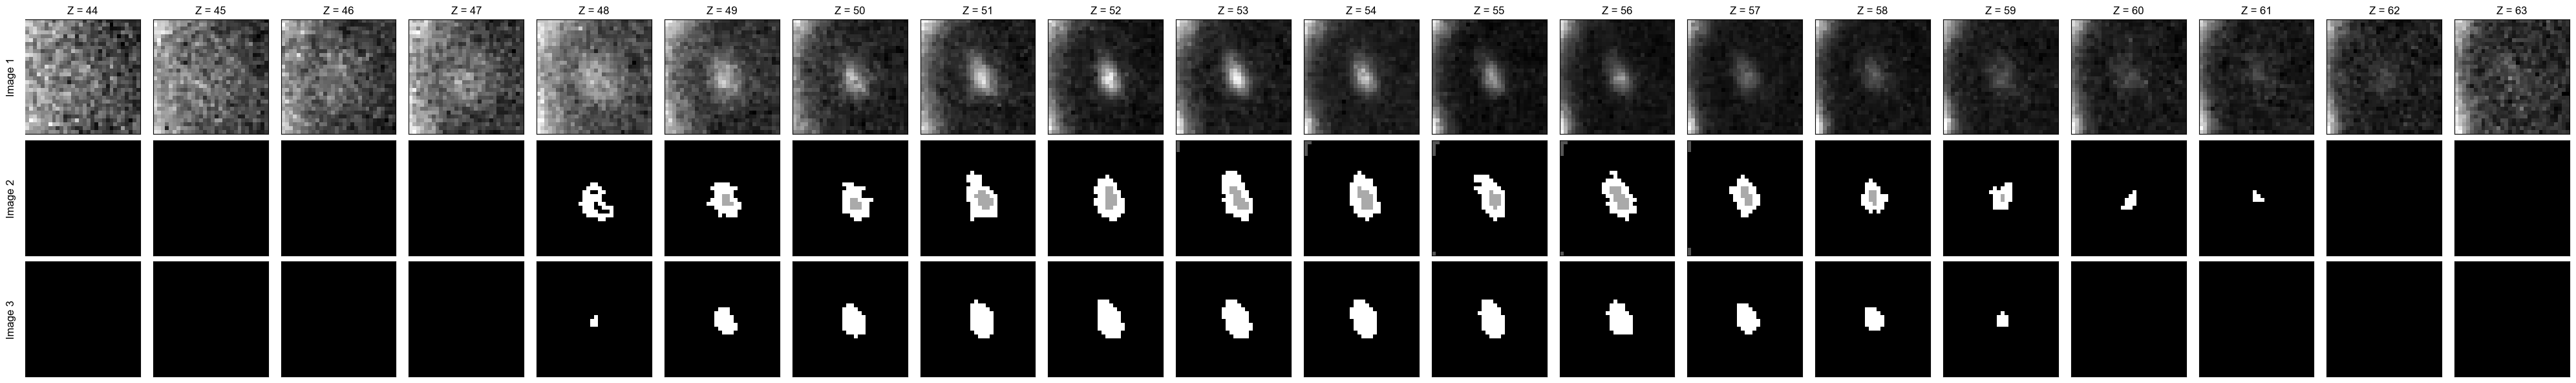

12 17
59 503


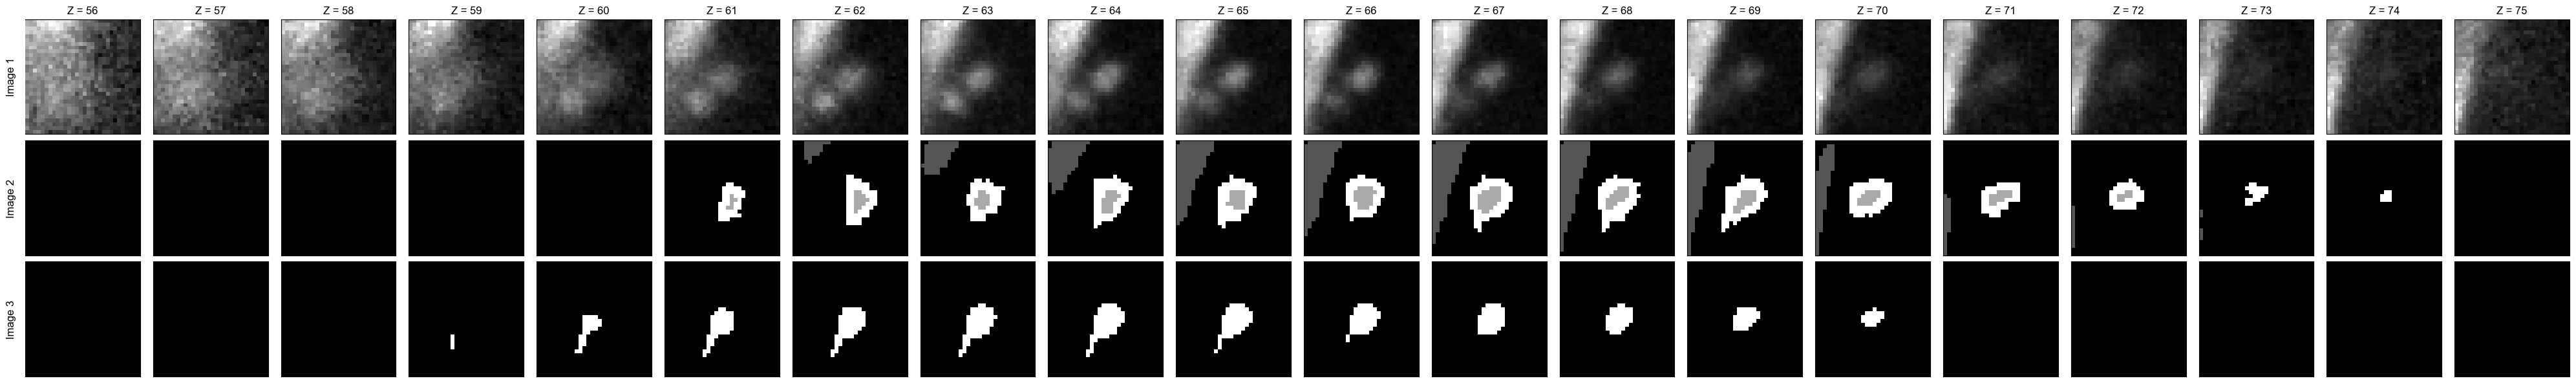

In [ ]:
for i,j in finaltoplt.iterrows():
    print(i,j['Target_ID'])
    xcor = j['Corrected_X']-15
    ycor = j['Corrected_Y']-15
    sz = j['Z_Slice']-10
    
    if ycor<1:
        ycor=1
    print(xcor, ycor)
    extract_and_plot_tiles([f3,f1, f2], start_z=j['Z_Slice']-10, num_tiles=20, x=xcor, y=ycor)

NameError: name 'd' is not defined

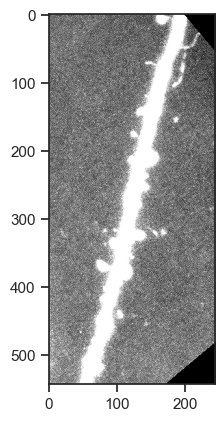

In [ ]:
import tifffile
import numpy as np
tif_path = r"Z:\2026 - E19 Project collab spine and dendrites\Respan\202607013_makingCAREmodel_deconvolution+GaussianFilter\nocare_MS\TEST1\New folder 1\bla.tif"
level = 170
window_width = 65

vmin = level - (window_width / 2)
vmax = level + (window_width / 2)
image = tifffile.imread(tif_path)
mip = np.max(image, axis=0)
# Display with matplotlib using the calculated window level bounds
plt.imshow(mip, cmap='gray', vmin=vmin, vmax=vmax)
# plt.colorbar(label='Intensity (Window Adjusted)')
# plt.figure(figsize=[2,6])
plt.plot(d['X'], d['Y'], '.')
for x, y, label in zip(d['X'], d['Y'], d['Target_ID']):
    plt.annotate(str(label), (x, y))
# plt.gca().invert_yaxis()